# This notebook contains code to generate the plots for the paper

In [10]:
%matplotlib inline
import itertools
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import io
from contextlib import contextmanager, redirect_stdout, redirect_stderr
from collections import defaultdict, OrderedDict
import pandas as pd
from ast import literal_eval
from tqdm import tqdm
import pennylane as qml
import glob
import matplotlib.ticker as ticker
from matplotlib import font_manager
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

from qugen.main.visualization.plot_images import plot_images_by_input_modes



In [2]:
SAVE_PLOTS_TO_DISK = True

if SAVE_PLOTS_TO_DISK:
    os.makedirs("plots_paper", exist_ok=True)

### General matplotlib settings for consistent style in all plots

In [3]:
import matplotlib.font_manager as font_manager

plt.rc ('font', size = 15) # steuert die Standardtextgröße
plt.rc ('axes', labelsize = 15) # Schriftgröße der x- und y-Beschriftungen
plt.rc ('xtick', labelsize = 12) #Schriftgröße der x-Tick-Labels
plt.rc ('ytick', labelsize = 12) #Schriftgröße der y-Tick-Labels
plt.rc ('legend', fontsize = 12) #Schriftgröße der Legende

font_dirs = ['fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

plt.rcParams['font.family'] = 'Times New Roman'   # normal text in TNR
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

color_palette = {
    'blue': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
    'red': (0.8352941176470589, 0.3686274509803922, 0.0),
    'green': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
    'orange': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
    'pink': (0.8,  0.47058823529411764,  0.7372549019607844), 
    'yellow': (0.9254901960784314, 0.8823529411764706, 0.2),
    'gray': (0.9, 0.9, 0.9)
    }

marker = {
    "circle": "o",
    "diamond": "d",
    "square": "s",
    "triangle": "^",
    "triangle_down": "v",
}

data_labels = {
    "fashion_mnist": "Fashion MNIST",
    "cifar10": "CIFAR-10"
}

marker_size = 8
line_width = 2
markeredgewidth = 1
handlelength = 1.5


TILE_SIZE=1.2
TILE_SEP=0.1
COL_SEP=0.3

In [4]:
@contextmanager
def silent(silence_errors=False):
    """
    Suppress prints to stdout. If silence_errors=True, also suppress stderr.
    Usage:
        with silent(): some_function()
        with silent(silence_errors=True): some_function()
    """
    with open(os.devnull, "w") as devnull:
        if silence_errors:
            with redirect_stdout(devnull), redirect_stderr(devnull):
                yield
        else:
            with redirect_stdout(devnull):
                yield

# Figure 3: QGAN samples for MNIST, Fashion-MNIST, and SVHN

## Figure 3a and 3b: MNIST and Fashion-MNIST grayscale images

In [5]:
mnist_modes = {
    0: [4, 9, 21, 35,],
    1: [5, 10, 16, 18, 36,],
    2: [6, 24, 15, 17, ],
    3: [12, 23, 38, 34],
    4: [8, 25, 28, 30],
    5: [3, 33, 0],
    6: [22, 27, 39],
    7: [1, 20, 26, 37,],
    8: [7, 14, 29, 31, 32, 19],
    9: [2, 11, 13, ],
}
mnist_modes_lin = list(itertools.chain.from_iterable(mnist_modes.values()))

fashion_mnist_modes = {
    "t-shirt/top":	[12, 16, 20, 3],
    "trouser":	[7, 15, 19, 32,],
    "pullover":	[30, 31, 33, 36,],
    "dress":		[6, 23, 37, 39,],
    "coat":		[22, 5, 26,  29,],
    "sandal":	[8, 14, 24, 27,],
    "shirt":		[2, 28,  34, 35,],
    "sneaker":	[9, 13, 18, 25,],
    "bag":		[1, 4, 11, 38,],
    "ankle boot":	[0, 10, 17, 21,],
}
fashion_mnist_modes_lin = list(itertools.chain.from_iterable(fashion_mnist_modes.values()))

In [6]:

with silent():
    _, _, all_samples_large_mnist = plot_images_by_input_modes("experiments/continuous_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_8921f0fc", epoch=37_000,  n_per_mode=500, apply_pca_per_mode=0, seed=2, compact_subplots=(4, 10, 1, 1), mode_order=mnist_modes_lin, save_path=None)
plt.clf()
with silent():
    _, _, all_samples_large_fmnist = plot_images_by_input_modes("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_c5f811fc", epoch=47_000, n_per_mode=500, apply_pca_per_mode=0, seed=2, compact_subplots=(4, 10, 1, 1), mode_order=fashion_mnist_modes_lin, save_path=None, invert_colors=True)
plt.clf()

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

In [7]:
def plot_encoding_circuits_consistent_spacing(
    rows_labels, cols_labels,
    images = None,
    grid_shape=(2, 4),      # tiles per block (rows, cols)
    tile_size=1.2,          # inches per tile
    tile_sep=0.2,           # inches between tiles (same x & y)
    row_sep=1.0,            # inches between the two block rows
    col_sep=1.0,            # inches between the two block columns
    margins=(1.0, 0.8, 0.9, 0.8),  # (left, right, top, bottom) inches
    title_pad_in=0.35,      # extra space (inches) above top blocks for column titles
    row_label_pad_in=0.35,  # space to the left of blocks for row labels
    seed=None,
    cmap="gray",
    save_path=None,
):
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    block_rows, block_cols = grid_shape

    # Per-block size (identical for all 4 blocks)
    block_w_in = block_cols * tile_size + (block_cols - 1) * tile_sep
    block_h_in = block_rows * tile_size + (block_rows - 1) * tile_sep

    n_rows = len(rows_labels)     # 2
    n_cols = len(cols_labels)     # 2

    L, R, T, B = margins

    # Figure size (inches)
    content_w_in = n_cols * block_w_in + (n_cols - 1) * col_sep
    content_h_in = n_rows * block_h_in + (n_rows - 1) * row_sep
    fig_w_in = L + content_w_in + R
    fig_h_in = T + title_pad_in + content_h_in + B

    # Fractions per inch for conversion
    fx = 1.0 / fig_w_in
    fy = 1.0 / fig_h_in

    fig = plt.figure(figsize=(fig_w_in, fig_h_in))

    # Top Y (fraction) where top of the top blocks sit (titles go above this)
    y_top_blocks = 1.0 - (T + title_pad_in) * fy

    # Draw tiles block-by-block using absolute positions
    for i in range(n_rows):
        for j in range(n_cols):
            # top-left of this block in inches
            x0_in = L + j * (block_w_in + col_sep)
            y_top_in = T + title_pad_in + i * (block_h_in + row_sep)

            # Place each tile inside the block, aligned to the block's top-left
            for r in range(block_rows):
                for c in range(block_cols):
                    x_in = x0_in + c * (tile_size + tile_sep)
                    y_in_top = y_top_in + r * (tile_size + tile_sep)
                    y_in = fig_h_in - y_in_top - tile_size  # bottom origin
                    rect = [x_in * fx, y_in * fy, tile_size * fx, tile_size * fy]
                    ax = fig.add_axes(rect)
                    if images is not None:
                        img = next(images)
                        ax.imshow(img, vmin=0, vmax=1,
                                  cmap=cmap, interpolation="nearest")
                    else:
                        ax.imshow(rng.random((32, 32), dtype=np.float32),
                                  cmap=cmap, interpolation="nearest")
                    ax.set_axis_off()

    # Column titles centered over each column of blocks
    for j, clabel in enumerate(cols_labels):
        x0_in = L + j * (block_w_in + col_sep)
        x1_in = x0_in + block_w_in
        x_mid = (x0_in + x1_in) * 0.5 * fx
        fig.text(x_mid, y_top_blocks + 0.5 * title_pad_in * fy, clabel,
                 ha="center", va="bottom", fontsize=16)

    # Row labels centered along each row of blocks
    for i, rlabel in enumerate(rows_labels):
        y0_in = T + title_pad_in + i * (block_h_in + row_sep)
        y1_in = y0_in + block_h_in
        y_mid = (fig_h_in - (y0_in + y1_in) * 0.5) * fy  # bottom-origin to fig fraction
        x_text = (L - row_label_pad_in) * fx
        fig.text(x_text, y_mid, rlabel, ha="right", va="center",
                 fontsize=16, rotation=90)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()


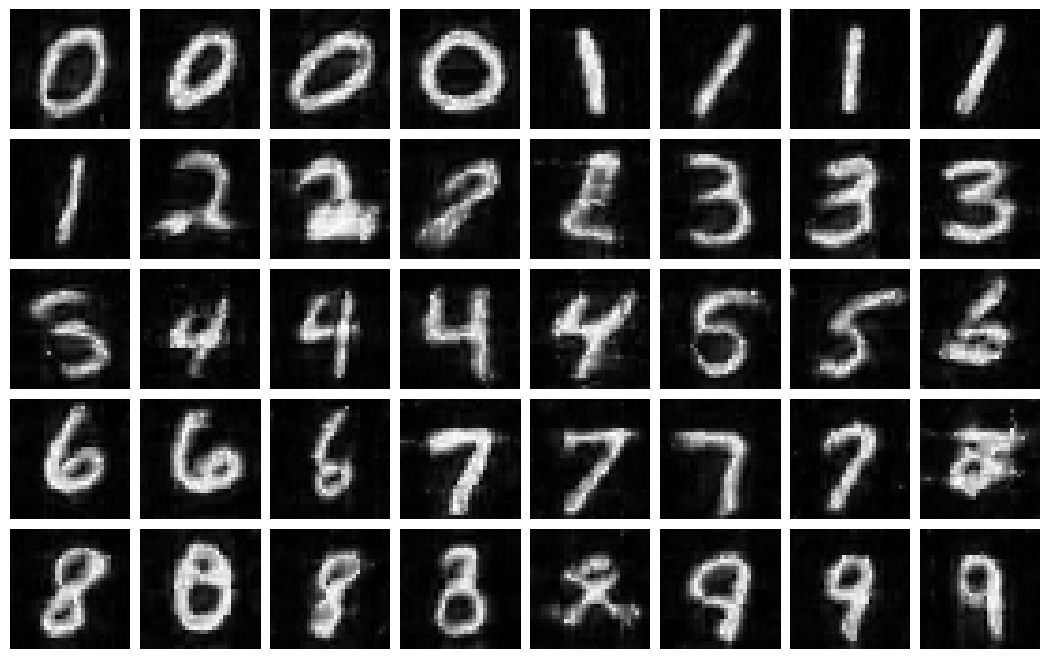

In [8]:
rows_labels = [None]
cols_labels = [None]
plot_encoding_circuits_consistent_spacing(
    rows_labels, cols_labels,
    images=iter(all_samples_large_mnist.reshape(40, 32, 32)),
    grid_shape=(5, 8),
    tile_size=TILE_SIZE,
    tile_sep=TILE_SEP,
    row_sep=COL_SEP,
    col_sep=COL_SEP,
    margins=(1.0, 0.8, 0.9, 0.8),
    title_pad_in=0.35,
    row_label_pad_in=0.35,
    seed=42,
    save_path="plots_paper/fig3a.pdf" if SAVE_PLOTS_TO_DISK else None
)

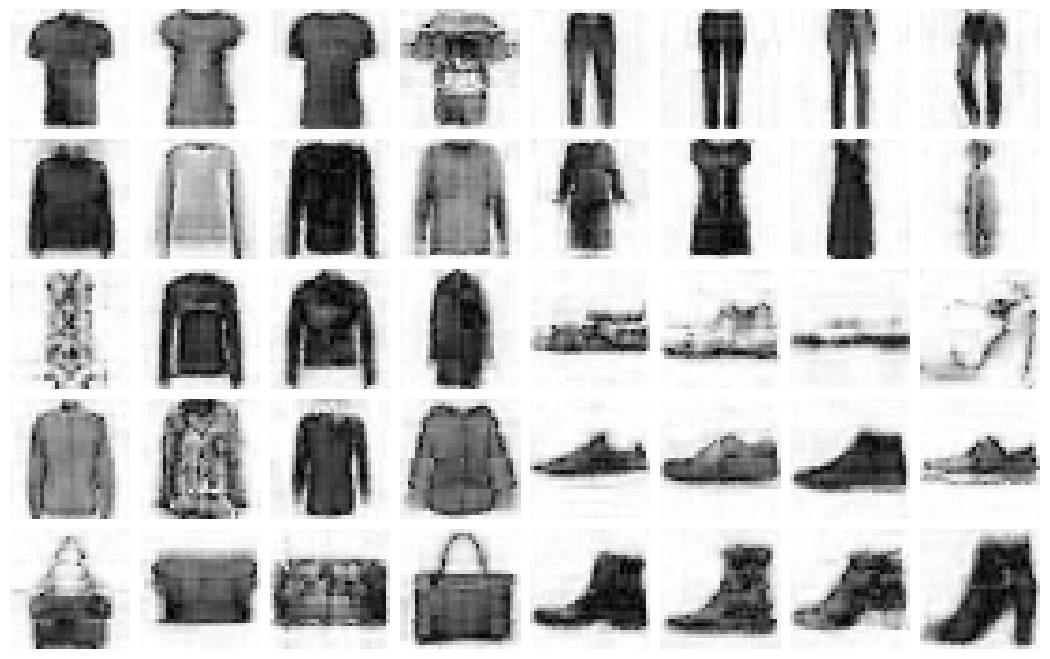

In [9]:
rows_labels = [None]
cols_labels = [None]
plot_encoding_circuits_consistent_spacing(
    rows_labels, cols_labels,
    images=iter(all_samples_large_fmnist.reshape(40, 32, 32)),
    grid_shape=(5, 8),
    tile_size=TILE_SIZE,
    tile_sep=TILE_SEP,
    row_sep=COL_SEP,
    col_sep=COL_SEP,
    margins=(1.0, 0.8, 0.9, 0.8),
    title_pad_in=0.35,
    row_label_pad_in=0.35,
    seed=42,
    cmap="gray_r",
    save_path="plots_paper/fig3b.pdf" if SAVE_PLOTS_TO_DISK else None
)

## Figure 3c: SVHN color images

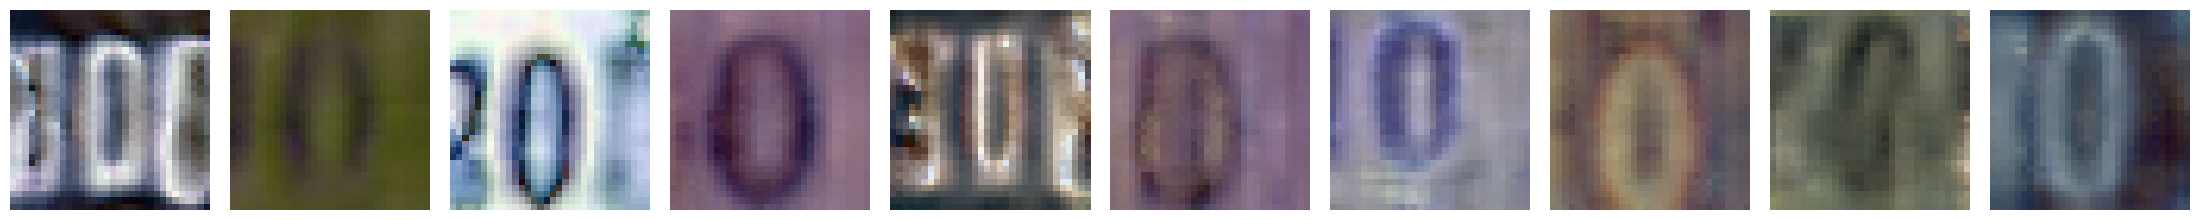

In [10]:
import numpy as np
import matplotlib.pyplot as plt

iteration = 59100
images = np.load(
    f"experiments/continuous_svhn_0_32x32_N_45550_minmax_qgan_ba56d178/samples_iteration={iteration}.npy"
)
images = images.reshape(-1, 32, 32, 3)

# Parameters
n_images = 10
TILE_SIZE = 2.0   # in inches
TILE_SEP  = 0.2   # in inches

# Compute figure size (width = n_tiles * size + (n_tiles-1)*sep)
total_width = n_images * TILE_SIZE + (n_images - 1) * TILE_SEP
fig_height = TILE_SIZE

fig, axs = plt.subplots(1, n_images, figsize=(total_width, fig_height))

for i, image in enumerate(images[:n_images]):
    axs[i].imshow(image, interpolation="nearest")
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_frame_on(False)


# Adjust spacing: TILE_SEP / TILE_SIZE gives fraction of axis width
fig.subplots_adjust(
    left=0, right=1, top=1, bottom=0, wspace=TILE_SEP / TILE_SIZE
)

if SAVE_PLOTS_TO_DISK:
    plt.savefig("plots_paper/fig3c.pdf", bbox_inches="tight")
plt.show()

# Figure 4: Effect of generator depth and dataset complexity on image quality

In [ ]:
# Note that 5 classes experiments were not used in the paper plots

# Define some useful constants for the experiments
LAYERS_8 = 0
LAYERS_16 = 1
LAYERS_32 = 2
CLASSES_2 = 0
CLASSES_5 = 1
CLASSES_10 = 2

LAYERS = (LAYERS_8, LAYERS_16, LAYERS_32)
CLASSES = (CLASSES_2, CLASSES_5, CLASSES_10)
N_LAYERS = len(LAYERS)
N_CLASSES = len(CLASSES)

LAYERS_DICT = {
    LAYERS_8: 8,
    LAYERS_16: 16,
    LAYERS_32: 32
}
assert len(LAYERS_DICT) == N_LAYERS, "LAYERS_DICT must contain all layer indices"
CLASSES_DICT = {
    CLASSES_2: 2,
    CLASSES_5: 6,
    CLASSES_10: 10
}
assert len(CLASSES_DICT) == N_CLASSES, "CLASSES_DICT must contain all class indices"

n_epochs = np.full((N_CLASSES, N_LAYERS), -1, dtype=int)

In [ ]:
# Organize the MNIST experiment paths by number of classes (x-axis in plot) and model size (y-axis in plot)
experiment_paths = np.full((N_CLASSES, N_LAYERS), None, dtype=object)
experiment_paths[CLASSES_2, LAYERS_8], n_epochs[CLASSES_2, LAYERS_8]= "experiments/continuous_mnist_0_1_32x32_N_12665_minmax_qgan_f2e2366e", 29500
experiment_paths[CLASSES_5, LAYERS_8], n_epochs[CLASSES_5, LAYERS_8] = None, 0
experiment_paths[CLASSES_10, LAYERS_8], n_epochs[CLASSES_10, LAYERS_8] = "experiments/continuous_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_f3be62bc", 35500

experiment_paths[CLASSES_5, LAYERS_16], n_epochs[CLASSES_5, LAYERS_16] = None, 0
experiment_paths[CLASSES_10, LAYERS_16], n_epochs[CLASSES_10, LAYERS_16] = "experiments/continuous_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_dbe9b988", 30600

experiment_paths[CLASSES_5, LAYERS_32], n_epochs[CLASSES_5, LAYERS_32] = None, 0
experiment_paths[CLASSES_10, LAYERS_32], n_epochs[CLASSES_10, LAYERS_32] = "experiments/continuous_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_c90b8717", 38500

In [ ]:
# Generate images for each experiment (utilizing plot_images_by_input_modes)
images = np.full((N_CLASSES, N_LAYERS), None, dtype=object)
for cls_idx in range(len(CLASSES)):
    for n_lay_idx in range(len(LAYERS)):
        path = experiment_paths[cls_idx, n_lay_idx]
        if path is not None:
            # suppress prints from plot_images_by_input_modes
            print(path)
            ep = n_epochs[cls_idx, n_lay_idx]
            if ep == -1:
                ep = None
            with silent():
                fig, _, samples = plot_images_by_input_modes(
                    path,
                    epoch=ep,
                    n_per_mode=4,
                    n_channels=1,
                    seed=2
                )
                plt.close(fig); del fig
            print(f"Generated images ({CLASSES_DICT[cls_idx]} classes and {LAYERS_DICT[n_lay_idx]} layers)")

            images[cls_idx, n_lay_idx] = samples

In [ ]:
MODE_TO_CLASS_DICT = np.full((N_CLASSES, N_LAYERS), None, dtype=object)

MODE_TO_CLASS_DICT[CLASSES_2, LAYERS_8] = {0: (0, 0), 1: (1, 1)}
assert (len(set(MODE_TO_CLASS_DICT[CLASSES_2, LAYERS_8].keys())) == 2
        and len(set(MODE_TO_CLASS_DICT[CLASSES_2, LAYERS_8].values())) == 2)


MODE_TO_CLASS_DICT[CLASSES_2, LAYERS_16] = {0: 0, 1: 1}
assert (len(set(MODE_TO_CLASS_DICT[CLASSES_2, LAYERS_16].keys())) == 2
        and len(set(MODE_TO_CLASS_DICT[CLASSES_2, LAYERS_16].values())) == 2)

MODE_TO_CLASS_DICT[CLASSES_5, LAYERS_8] = {0: 3, 1: 1, 2: 4, 3: 2, 4: 5, 5: 0}
assert (len(set(MODE_TO_CLASS_DICT[CLASSES_5, LAYERS_8].keys())) == 6
        and len(set(MODE_TO_CLASS_DICT[CLASSES_5, LAYERS_8].values())) == 6)


MODE_TO_CLASS_DICT[CLASSES_5, LAYERS_16] = {0: 2, 1: 3, 2: 1, 3: 4, 4: 5, 5: 0}
assert (len(set(MODE_TO_CLASS_DICT[CLASSES_5, LAYERS_16].keys())) == 6
        and len(set(MODE_TO_CLASS_DICT[CLASSES_5, LAYERS_16].values())) == 6)



MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_8] = {
 0: (7, 1),
 1: (9, 1),
 2: (2, 3),
 3: (4, 2),
 4: (8, 2),
 5: (1, 1),
 6: (5, 0),
 7: (6, 2),
 8: (0, 2),
 9: (3, 3)
}
assert (len(set(MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_8].keys())) == 10
        and len(set(MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_8].values())) == 10)





MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_16] = {
 0: (2, 1),
 1: (9, 0),
 2: (5, 0),
 3: (6, 2),
 4: (1, 0),
 5: (7, 1),
 6: (3, 1),
 7: (4, 3),
8: (0, 0),
 9: (8, 0),
}
assert (len(set(MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_16].keys())) == 10
        and len(set(MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_16].values())) == 10)



MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_32] = \
{0: (5, 2),
 1: (7, 0),
 2: (0,0),
 3: (6, 2),
 4: (2, 1),
 5: (1, 0),
 6: (4, 2),
 7: (3, 3),
 8: (9, 0),
 9: (8, 0)
}
assert (len(set(MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_32].keys())) == 10
        and len(set(MODE_TO_CLASS_DICT[CLASSES_10, LAYERS_32].values())) == 10)


# automatically create the reverse mapping:
CLASS_TO_MODE_DICT = np.full((N_CLASSES, N_LAYERS), None, dtype=object)
for cls_idx in range(N_CLASSES):
    for n_lay_idx in range(N_LAYERS):
        if MODE_TO_CLASS_DICT[cls_idx, n_lay_idx] is not None:
            CLASS_TO_MODE_DICT[cls_idx, n_lay_idx] = {
                v: k for k, v in MODE_TO_CLASS_DICT[cls_idx, n_lay_idx].items()
            }


In [ ]:
# Create four subplots for the reduced plotting
fig, axs = plt.subplots(1, 4, figsize=(10, 1.75), gridspec_kw={'width_ratios': [1, 5, 5, 5]}, squeeze=True)
fig.subplots_adjust(wspace=1, )
settings_to_plot = [
    (CLASSES_2, LAYERS_8),
    (CLASSES_10, LAYERS_8),
    (CLASSES_10, LAYERS_16),
    (CLASSES_10, LAYERS_32)
]

all_images = []

for ax, (cls_idx, n_lay_idx) in zip(axs, settings_to_plot):
    ax.axis('off')

    imgs = images[cls_idx, n_lay_idx]
    imgs = {digit: imgs[mode_i][sample_i] for mode_i, (digit, sample_i) in MODE_TO_CLASS_DICT[cls_idx, n_lay_idx].items()}
    imgs = [imgs[digit] for digit in sorted(imgs.keys())]

    n_grid_rows = 2
    n_grid_cols = len(imgs) // n_grid_rows

    # create inset axes for each image
    inset_margin_total = 0.05
    inset_margin_h = inset_margin_total / n_grid_cols
    inset_margin_v = inset_margin_total / n_grid_rows
    inset_width = 1 / n_grid_cols - inset_margin_h
    inset_height = 1 / n_grid_rows - inset_margin_v
    for x in range(n_grid_cols):
        for y in range(n_grid_rows):
            idx = x * n_grid_rows + y
            if idx < len(imgs):
                ax_inset = ax.inset_axes([x * (inset_width + inset_margin_h),
                                                1 - (y + 1) * (inset_height + inset_margin_v),
                                                inset_width,
                                                inset_height],)
                ax_inset.imshow(img := imgs[idx].reshape(32, 32), cmap='gray', vmin=0, vmax=1, interpolation='nearest')
                all_images.append(img)
                ax_inset.axis('off')
plt.close(fig); del fig


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_depth_columns_consistent_spacing(
    configs,                 # [(label, rows, cols), ...]
    images=None,            # iterator or list of images to plot (if None, random noise is used)
    tile_size=1.2,           # inches per tile (square)
    tile_sep=0.2,            # inches between tiles (same for x and y)
    col_sep=0.8,             # inches between the column groups
    margins=(1.0, 0.8, 0.8, 0.6),  # (left, right, top, bottom) inches
    title_pad_in=0.3,        # inches from top of image grid to column title
    bottom_pad_in=0.4,       # inches below images for labels
    seed=42,
    save_path=None
):
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    n_cols = len(configs)

    # Per-column grid sizes in inches
    col_widths_in = [(c * tile_size + (c - 1) * tile_sep) for (_, r, c) in configs]
    col_heights_in = [(r * tile_size + (r - 1) * tile_sep) for (_, r, c) in configs]
    content_height_in = max(col_heights_in)

    L, R, T, B = margins
    fig_w_in = L + sum(col_widths_in) + (n_cols - 1) * col_sep + R
    fig_h_in = T + title_pad_in + content_height_in + bottom_pad_in + B

    fig = plt.figure(figsize=(fig_w_in, fig_h_in))

    fx = 1.0 / fig_w_in
    fy = 1.0 / fig_h_in

    y_top_images = 1.0 - (T + title_pad_in) * fy

    x_cursor_in = L
    for (label, rows, cols), w_in, h_in in zip(configs, col_widths_in, col_heights_in):
        x0f = x_cursor_in * fx
        x1f = (x_cursor_in + w_in) * fx
        y1f = y_top_images
        y0f = (y_top_images - content_height_in * fy)

        # Title
        fig.text((x0f + x1f) / 2.0, y1f + 0.5 * title_pad_in * fy, label,
                 ha="center", va="bottom", fontsize=24)

        # Tiles
        for c in range(cols):
            for r in range(rows):
                x_in = x_cursor_in + c * (tile_size + tile_sep)
                y_in_top = T + title_pad_in + r * (tile_size + tile_sep)
                y_in = fig_h_in - y_in_top - tile_size
                rect = [x_in * fx, y_in * fy, tile_size * fx, tile_size * fy]
                ax = fig.add_axes(rect)
                if images is not None:
                    ax.imshow(next(images),
                              cmap="gray", interpolation="nearest")
                else:
                    ax.imshow(rng.random((32, 32), dtype=np.float32),
                              cmap="gray", interpolation="nearest")
                ax.set_axis_off()
        x_cursor_in += w_in + col_sep


    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()



In [ ]:

configs = [("2 classes\n8 layers", 2, 1),
           ("10 classes, 8 layers\n(FID: 157)", 2, 5),
           ("10 classes, 16 layers\n(FID: 139)", 2, 5),
           ("10 classes, 32 layers\n(FID: 109)", 2, 5),
           ]  # note that FID scores are hard-coded here for the paper figure (computed via FID_and_MMD_evaluation.ipynb)

In [ ]:
plot_depth_columns_consistent_spacing(
    configs=configs,
    images=iter(all_images),
    tile_size=TILE_SIZE,
    tile_sep=TILE_SEP,
    col_sep=COL_SEP,
    margins=(1.0, 0.8, 0.9, 0.8),
    title_pad_in=0.15,
    bottom_pad_in=0.4,
    seed=42,
    save_path="plots_paper/fig12.pdf" if SAVE_PLOTS_TO_DISK else None
)

# Figure 5: Ablation study of circuit and encoding choices

/var/folders/7_/vz1nj3hx5psd4x1v80v8lrch0000gn/T/ipykernel_56283/616839769.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


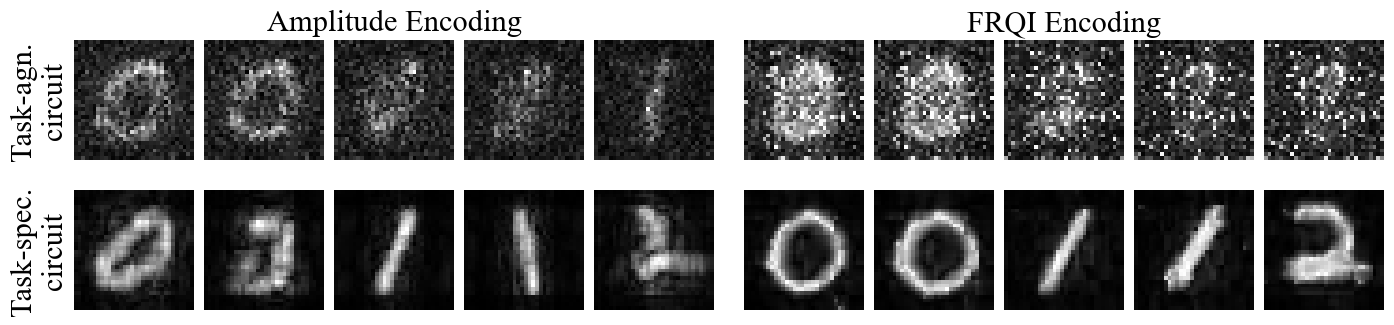

In [11]:
import numpy as np

TILE_SIZE=1.2
TILE_SEP=0.1
COL_SEP=0.3

def plot_encoding_circuits_consistent_spacing(
    rows_labels, cols_labels,
    grid_shape=(2, 4),      # tiles per block (rows, cols)
    tile_size=1.2,          # inches per tile
    tile_sep=0.2,           # inches between tiles (same x & y)
    row_sep=1.0,            # inches between the two block rows
    col_sep=1.0,            # inches between the two block columns
    margins=(1.0, 0.8, 0.9, 0.8),  # (left, right, top, bottom) inches
    title_pad_in=0.35,      # extra space (inches) above top blocks for column titles
    row_label_pad_in=0.35,  # space to the left of blocks for row labels
    samples=None
):
    block_rows, block_cols = grid_shape

    # Per-block size (identical for all 4 blocks)
    block_w_in = block_cols * tile_size + (block_cols - 1) * tile_sep
    block_h_in = block_rows * tile_size + (block_rows - 1) * tile_sep

    n_rows = len(rows_labels)     # 2
    n_cols = len(cols_labels)     # 2

    L, R, T, B = margins

    # Figure size (inches)
    content_w_in = n_cols * block_w_in + (n_cols - 1) * col_sep
    content_h_in = n_rows * block_h_in + (n_rows - 1) * row_sep
    fig_w_in = L + content_w_in + R
    fig_h_in = T + title_pad_in + content_h_in + B

    # Fractions per inch for conversion
    fx = 1.0 / fig_w_in
    fy = 1.0 / fig_h_in

    fig = plt.figure(figsize=(fig_w_in, fig_h_in))

    # Top Y (fraction) where top of the top blocks sit (titles go above this)
    y_top_blocks = 1.0 - (T + title_pad_in) * fy

    # Draw tiles block-by-block using absolute positions
    # for i in range(n_rows):
    for i, circ in enumerate(["se_circ", "frqi_circ"]):
        # for j in range(n_cols):
        for j, enc in enumerate(["amp_enc", "frqi_enc"]):
            # top-left of this block in inches
            x0_in = L + j * (block_w_in + col_sep)
            y_top_in = T + title_pad_in + i * (block_h_in + row_sep)

            # Place each tile inside the block, aligned to the block's top-left
            counter = 0

            indices = {
                "se_circ_frqi_enc": [1, 2, 0, 3, 4],
                "se_circ_amp_enc": [1, 2, 3, 4, 0],
                "frqi_circ_frqi_enc": [1, 2, 3, 4, 0],
                "frqi_circ_amp_enc": [0, 4, 1, 2, 3]
            }
            for r in range(block_rows):
                for c in range(block_cols):
                    x_in = x0_in + c * (tile_size + tile_sep)
                    y_in_top = y_top_in + r * (tile_size + tile_sep)
                    y_in = fig_h_in - y_in_top - tile_size  # bottom origin
                    rect = [x_in * fx, y_in * fy, tile_size * fx, tile_size * fy]
                    ax = fig.add_axes(rect)
                    ax.imshow(samples[f"{circ}_{enc}"][indices[f"{circ}_{enc}"][counter]], cmap="gray", interpolation="nearest")
                    ax.set_axis_off()
                    counter += 1


    # Column titles centered over each column of blocks
    for j, clabel in enumerate(cols_labels):
        x0_in = L + j * (block_w_in + col_sep)
        x1_in = x0_in + block_w_in
        x_mid = (x0_in + x1_in) * 0.5 * fx
        fig.text(x_mid, y_top_blocks + 0.5 * title_pad_in * fy, clabel,
                 ha="center", va="center", fontsize=22)

    # Row labels centered along each row of blocks
    for i, rlabel in enumerate(rows_labels):
        y0_in = T + title_pad_in + i * (block_h_in + row_sep)
        y1_in = y0_in + block_h_in
        y_mid = (fig_h_in - (y0_in + y1_in) * 0.5) * fy  # bottom-origin to fig fraction
        x_text = (L - row_label_pad_in) * fx
        fig.text(x_text-0., y_mid, rlabel, ha="center", va="center",
                 fontsize=22, rotation=90)
        # fig.text(x_text, y_mid, rlabel, ha="center", va="center",
        #          fontsize=18, rotation=90)

    plt.tight_layout()
    if SAVE_PLOTS_TO_DISK:
        plt.savefig("plots_paper/fig4.pdf")
    plt.show()

base_path = "experiments"
iteration = 15000

paths = {
    "se_circ_frqi_enc": "continuous_mnist_0_1_2_32x32_N_18623_minmax_qgan_174c8349",
    "se_circ_amp_enc": "continuous_mnist_0_1_2_32x32_N_18623_minmax_qgan_7f68e3ee",
    "frqi_circ_frqi_enc": "continuous_mnist_0_1_2_32x32_N_18623_minmax_qgan_a3edbcf3",
    "frqi_circ_amp_enc": "continuous_mnist_0_1_2_32x32_N_18623_minmax_qgan_7e20b476"
}

samples = {}

for key, path in paths.items():
    samples[key] = np.load(f"{base_path}/{path}/samples_iteration={iteration}.npy").reshape(-1, 32, 32)

rows_labels = ["Task-agn.\ncircuit", "Task-spec.\ncircuit"]
cols_labels = ["Amplitude Encoding", "FRQI Encoding"]
plot_encoding_circuits_consistent_spacing(
    rows_labels, cols_labels,
    grid_shape=(1, 5),
    tile_size=TILE_SIZE,
    tile_sep=TILE_SEP,
    row_sep=COL_SEP,
    col_sep=COL_SEP,
    margins=(1.0, 0.8, 0.9, 0.8),
    title_pad_in=0.35,
    row_label_pad_in=0.35,
    samples=samples
)


# Figure 6: Comparison of noise inputs (unimodal, multimodal w/o noise tuning, multimodal w/ noise tuning)

In [12]:
# Experiments are either single or multi-modal noise with different numbers of classes (3 vs 10)

single_3 = "experiments/continuous_mnist_0_1_2_32x32_N_18623_minmax_qgan_d241d4a5/samples_iteration=15000.npy"
multi_3 = "experiments/continuous_mnist_0_1_2_32x32_N_18623_minmax_qgan_a3edbcf3/samples_iteration=15000.npy"
multi_3_no_tuning = "experiments/continuous_mnist_0_1_2_32x32_N_18623_minmax_qgan_daa843cf/samples_iteration=10000.npy"

all_experiments = OrderedDict()
all_experiments["unimodal"] = single_3
all_experiments["no_tuning"] = multi_3_no_tuning
all_experiments["multimodal"] = multi_3

sample_indices = {
    "unimodal": [1, 3, 0, 6],
    "no_tuning": [1, 0, 14, 2],
    "multimodal": [1, 5, 0, 11],
}

In [13]:
file_name_prefix = "plots/comp_noise"
all_images = defaultdict(list)

for key, samples_path in all_experiments.items():

    loaded_samples = np.load(samples_path).reshape(-1, 32, 32)

    selected_samples = loaded_samples[sample_indices[key]]
    for i, img in enumerate(selected_samples):
        all_images[key].append(img)

In [14]:
def plot_encoding_circuits_consistent_spacing(
    rows_labels, cols_labels,
    images = None,
    grid_shape=(2, 4),      # tiles per block (rows, cols)
    tile_size=1.2,          # inches per tile
    tile_sep=0.2,           # inches between tiles (same x & y)
    row_sep=1.0,            # inches between the two block rows
    col_sep=1.0,            # inches between the two block columns
    margins=(1.0, 0.8, 0.9, 0.8),  # (left, right, top, bottom) inches
    title_pad_in=0.35,      # extra space (inches) above top blocks for column titles
    row_label_pad_in=0.35,  # space to the left of blocks for row labels
    seed=None,
    cmap="gray",
    save_path=None,
):
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    block_rows, block_cols = grid_shape

    # Per-block size (identical for all 4 blocks)
    block_w_in = block_cols * tile_size + (block_cols - 1) * tile_sep
    block_h_in = block_rows * tile_size + (block_rows - 1) * tile_sep

    n_rows = len(rows_labels)     # 2
    n_cols = len(cols_labels)     # 2

    L, R, T, B = margins

    # Figure size (inches)
    content_w_in = n_cols * block_w_in + (n_cols - 1) * col_sep
    content_h_in = n_rows * block_h_in + (n_rows - 1) * row_sep
    fig_w_in = L + content_w_in + R
    fig_h_in = T + title_pad_in + content_h_in + B

    # Fractions per inch for conversion
    fx = 1.0 / fig_w_in
    fy = 1.0 / fig_h_in

    fig = plt.figure(figsize=(fig_w_in, fig_h_in))

    # Top Y (fraction) where top of the top blocks sit (titles go above this)
    y_top_blocks = 1.0 - (T + title_pad_in) * fy

    # Draw tiles block-by-block using absolute positions
    for i in range(n_rows):
        for j in range(n_cols):
            # top-left of this block in inches
            x0_in = L + j * (block_w_in + col_sep)
            y_top_in = T + title_pad_in + i * (block_h_in + row_sep)

            # Place each tile inside the block, aligned to the block's top-left
            for r in range(block_rows):
                for c in range(block_cols):
                    x_in = x0_in + c * (tile_size + tile_sep)
                    y_in_top = y_top_in + r * (tile_size + tile_sep)
                    y_in = fig_h_in - y_in_top - tile_size  # bottom origin
                    rect = [x_in * fx, y_in * fy, tile_size * fx, tile_size * fy]
                    ax = fig.add_axes(rect)
                    if images is not None:
                        img = next(images)
                        ax.imshow(img, vmin=0, vmax=1,
                                  cmap=cmap, interpolation="nearest")
                    else:
                        ax.imshow(rng.random((32, 32), dtype=np.float32),
                                  cmap=cmap, interpolation="nearest")
                    ax.set_axis_off()

    # Column titles centered over each column of blocks
    for j, clabel in enumerate(cols_labels):
        x0_in = L + j * (block_w_in + col_sep)
        x1_in = x0_in + block_w_in
        x_mid = (x0_in + x1_in) * 0.5 * fx
        fig.text(x_mid, y_top_blocks + 0.5 * title_pad_in * fy, clabel,
                 ha="center", va="bottom", fontsize=16)

    # Row labels centered along each row of blocks
    for i, rlabel in enumerate(rows_labels):
        y0_in = T + title_pad_in + i * (block_h_in + row_sep)
        y1_in = y0_in + block_h_in
        y_mid = (fig_h_in - (y0_in + y1_in) * 0.5) * fy  # bottom-origin to fig fraction
        x_text = (L - row_label_pad_in) * fx
        fig.text(x_text, y_mid, rlabel, ha="right", va="center",
                 fontsize=16, rotation=90)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()

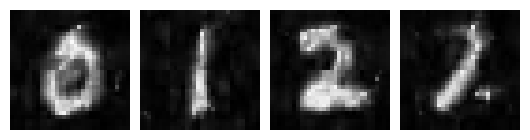

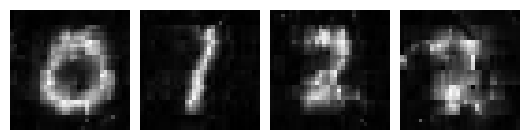

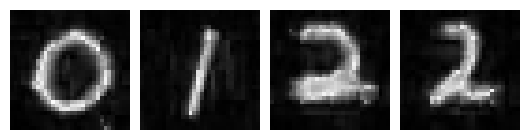

In [15]:
plot_save_path_lookup = {
    "unimodal": "plots_paper/fig5a.pdf",
    "no_tuning": "plots_paper/fig5b.pdf",
    "multimodal": "plots_paper/fig5c.pdf",
}

for key in all_experiments:
    plot_save_path = plot_save_path_lookup[key] if SAVE_PLOTS_TO_DISK else None

    plot_encoding_circuits_consistent_spacing(
        rows_labels=[None], cols_labels=[None],
        images=iter(np.array(all_images[key])),
        grid_shape=(1, 4),
        tile_size=TILE_SIZE,
        tile_sep=TILE_SEP,
        row_sep=COL_SEP,
        col_sep=COL_SEP,
        margins=(1.0, 0.8, 0.9, 0.8),
        title_pad_in=0.35,
        row_label_pad_in=0.35,
        seed=42,
        save_path=plot_save_path
    )

# Figure 7: More noise modes than classes (Overmoding)

In [16]:
n_modes = [10, 20, 40]  # Number of modes to visualize

In [17]:
# Generate samples
with silent():
    plot_images_by_input_modes("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_0533b651", epoch=20000, n_per_mode=1_000, apply_pca_per_mode=1, seed=42, compact_subplots=(2, 5, 1, 3), invert_colors=True)  # 10 modes
    plt.clf()
    plot_images_by_input_modes("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_e098dc80", epoch=20000, n_per_mode=1_000, apply_pca_per_mode=1, seed=42, compact_subplots=(4, 5, 1, 3), invert_colors=True)  # 20 modes
    plt.clf()
    plot_images_by_input_modes("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_cbf8da2e", epoch=36800, n_per_mode=1_000, apply_pca_per_mode=1, seed=42, compact_subplots=(8, 5, 1, 3), invert_colors=True)  # 40 modes
    plt.clf()

    # generate more samples per modes as needed later for FID evaluation in Patch-QGAN benchmark (to obtain 10000 samples among the considered two class subset, four modes each)
    plot_images_by_input_modes("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_cbf8da2e", epoch=36800, n_per_mode=1_250, apply_pca_per_mode=1, seed=42, compact_subplots=(8, 5, 1, 3), invert_colors=True)  # 40 modes
    plt.clf()

<Figure size 1500x200 with 0 Axes>

<Figure size 1500x400 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

In [18]:
# Assumes that the following samples were generated with the plot_images_by_input_modes function e.g. via image_visualization.ipynb

modes_10 = "experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_0533b651/images_by_mode/epoch=20000_n_per_mode=1000_seed=42.npz"
modes_20 = "experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_e098dc80/images_by_mode/epoch=20000_n_per_mode=1000_seed=42.npz"
modes_40 = "experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_cbf8da2e/images_by_mode/epoch=36800_n_per_mode=1000_seed=42.npz"

modes_10_data = np.load(modes_10)
modes_20_data = np.load(modes_20)
modes_40_data = np.load(modes_40)
all_data = [modes_10_data, modes_20_data, modes_40_data]

In [19]:
dress_10 = {1}
dress_20 = {0, 17}
dress_40 = {12, 26, 28, 34}
dress_all_modes = [dress_10, dress_20, dress_40]

In [20]:
boot_10 = {0}
boot_20 = {18, 5}
boot_40 = {4, 5, 29, 32}
boot_all_modes = [boot_10, boot_20, boot_40]

In [21]:
other_modes_10 = {3}
other_modes_20 = {12, 19}
#tshirts_40 = {8, 14, 21, 25}
other_modes_40 = {14, 12, 19, 25}  # these are actually inter-class modes
other_all_modes = [other_modes_10, other_modes_20, other_modes_40]

In [22]:
all_modes = [
    boot_all_modes,
    dress_all_modes,
    other_all_modes
             ]

In [23]:
num_modes = [len(modes) for modes in all_modes[0]]
print(num_modes)
max_num_modes = max(map(len, np.array(all_modes).flatten().tolist()))
print(f"Max number of modes to plot: {max_num_modes}")

[1, 2, 4]
Max number of modes to plot: 4


In [24]:
from qugen.main.visualization.plot_images import pca_images

fig, axs = plt.subplots(sum(num_modes), len(all_modes), figsize=(2 * max_num_modes, 5))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
img_layout_per_mode = (3, 1)

all_images = defaultdict(list)

for k, modes_class in enumerate(all_modes):

    for j, (data, modes) in enumerate(zip(all_data, modes_class)):
        n_used = len(modes)
        #start = round((max_num_modes - n_used) / 2)
        for i, mode in enumerate(modes):
            # get the images for the current mode
            #i = start + i
            images = data[f"{mode}"]

            # Apply PCA to obtain images:
            images, explained_var_rats = pca_images(images, n_components=1, std_factor=3.,
                                                    pick_closest=True, return_explained_var_ratio=True)
            images = images.reshape(-1, 32, 32)

            ax = axs[sum(num_modes[:j]) + i, k]
            ax.axis('off')

            inset_margin_total = 0.05
            inset_margin_h = inset_margin_total / img_layout_per_mode[0]
            inset_margin_v = inset_margin_total / img_layout_per_mode[1]
            inset_width = 1 / img_layout_per_mode[0] - inset_margin_h
            inset_height = 1 / img_layout_per_mode[1] - inset_margin_v

            # plot the images via inset plots
            for x in range(img_layout_per_mode[0]):
                for y in range(img_layout_per_mode[1]):
                    idx = x * img_layout_per_mode[1] + y
                    if idx < len(images):
                        ax_inset = ax.inset_axes([x * (inset_width + inset_margin_h),
                                                        1 - (y + 1) * (inset_height + inset_margin_v),
                                                        inset_width,
                                                        inset_height],)
                        ax_inset.imshow(img := images[idx].reshape(32, 32), cmap='gray_r', vmin=0, vmax=1)
                        all_images[f"{len(modes)}"].append(img)
                        ax_inset.axis('off')
plt.close(fig); del fig

Component 0: Explained variance ratio 40.72834777832031%
Component 0: Explained variance ratio 24.53407859802246%
Component 0: Explained variance ratio 32.05803680419922%
Component 0: Explained variance ratio 48.90837097167969%
Component 0: Explained variance ratio 38.809146881103516%
Component 0: Explained variance ratio 35.15272903442383%
Component 0: Explained variance ratio 29.230758666992188%
Component 0: Explained variance ratio 40.99919509887695%
Component 0: Explained variance ratio 41.65098190307617%
Component 0: Explained variance ratio 49.20780944824219%
Component 0: Explained variance ratio 48.270259857177734%
Component 0: Explained variance ratio 41.433162689208984%
Component 0: Explained variance ratio 46.62742233276367%
Component 0: Explained variance ratio 49.74251174926758%
Component 0: Explained variance ratio 65.4454116821289%
Component 0: Explained variance ratio 64.32257080078125%
Component 0: Explained variance ratio 51.79707336425781%
Component 0: Explained varia

9


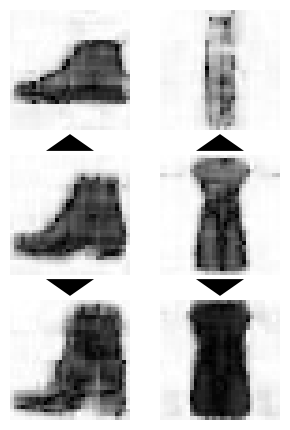

18


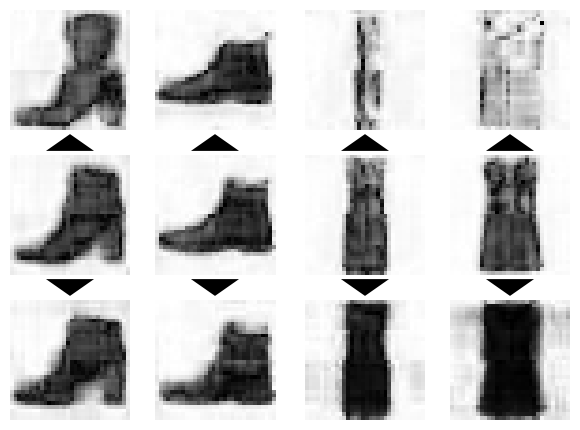

36


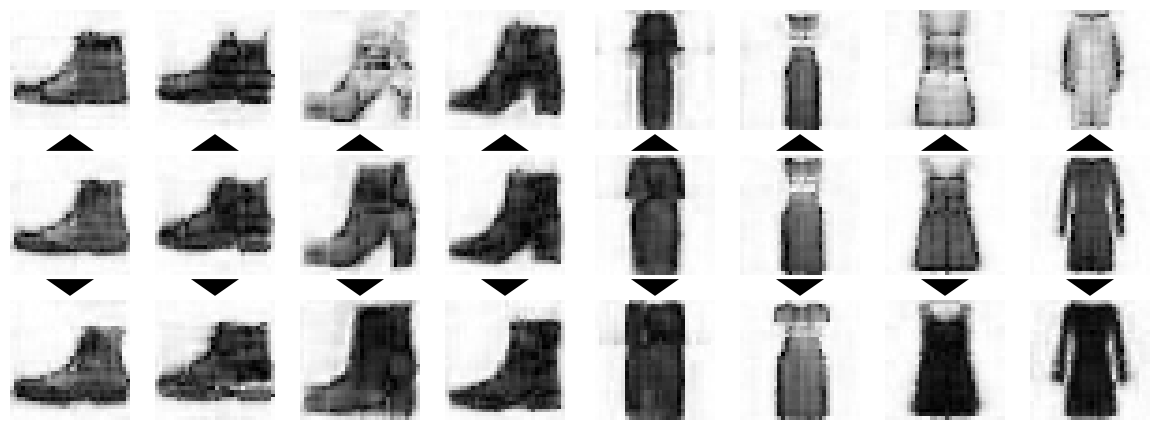

LaTeX width fractions (sum to 90% of \textwidth):
  Fig 0: 0.123350\textwidth
  Fig 1: 0.255838\textwidth
  Fig 2: 0.520812\textwidth


In [25]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# -------- geometry (in inches) --------
TILE_SIZE = 1.2  # tile width = tile height
ROW_SEP = 0.1  # horizontal gap between adjacent tile columns
COL_SEP = 0.3  # big middle horizontal gap between the two column blocks
ROW_SEP = 0.25  # vertical separation between rows  (increase as needed)

# -------- arrowhead style --------
# size is a fraction of the vertical gap height; tweak 0.35 ↔ 0.5 to taste
ARROW_SIZE_FRAC = 0.40
ARROW_FACE = "black"  # filled black heads
ARROW_EDGE = "none"  # no outline for a clean head-only look

# --- arrowhead style (same look as your previous polygon heads) ---
ARROW_FACE = "black"
ARROW_EDGE = "none"
base_half = 0.20  # fraction of axes height (wide base)
HEAD_LEN_FRAC = 0.40  # head length as a fraction of the gap width

"""
Narrow figures
"""


def plot_mode_vars(n_rows, n_cols_tiles, images_iter, save_path, rotate=False):
    # grid params
    if n_cols_tiles > 1:
        half = n_cols_tiles // 2
        n_gaps = n_cols_tiles - 1
    else:
        half = 1
        n_gaps = 1

    # figure size
    total_gap_w = (n_gaps - 1) * ROW_SEP + (COL_SEP if n_gaps >= 1 else 0.0)
    total_width = n_cols_tiles * TILE_SIZE + total_gap_w
    fig_height = n_rows * TILE_SIZE + (n_rows - 1) * ROW_SEP

    fig = plt.figure(figsize=(total_width, fig_height))

    # GridSpec with explicit gap columns to avoid clipping
    n_cols_total = 2 * n_cols_tiles - 1
    width_ratios = []
    for gap_idx in range(n_cols_tiles - 1):
        width_ratios.append(1.0)  # tile column (in TILE_SIZE units)
        width_ratios.append(COL_SEP / TILE_SIZE if gap_idx == (half - 1)
                            else ROW_SEP / TILE_SIZE)
    width_ratios.append(1.0)  # last tile column

    gs = fig.add_gridspec(
        nrows=n_rows,
        ncols=n_cols_total,
        width_ratios=width_ratios,
        wspace=0.0,  # horizontal spacing via gap columns
        hspace=ROW_SEP / TILE_SIZE  # vertical spacing so gap = ROW_SEP
    )
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # create axes only on tile columns
    axs = []
    for r in range(n_rows):
        row_axes = []
        for t in range(n_cols_tiles):
            c = 2 * t  # even indices = tiles
            ax = fig.add_subplot(gs[r, c])
            row_axes.append(ax)
        axs.append(row_axes)

    # draw tiles
    for t in range(n_cols_tiles):
        for r in range(n_rows):
            ax = axs[r][t]
            img = next(images_iter)
            if rotate:
                img = np.rot90(img, k=1)
            ax.imshow(img, cmap="gray_r", interpolation="nearest")
            ax.set_axis_off()

    # ---- arrowheads only (black), centered in the gaps above/below middle row ----
    mid_r = n_rows // 2  # 1 for 3 rows
    gap_frac = ROW_SEP / TILE_SIZE  # gap height in axes-fraction units
    radius = ARROW_SIZE_FRAC * gap_frac  # triangle radius relative to gap

    for ax in axs[mid_r]:
        # center positions (axes fraction coords)
        x = 0.5
        y_up = 1.0 + 0.5 * gap_frac
        y_down = 0.0 - 0.5 * gap_frac

        height = 0.07  # vertical size

        up_vertices = [
            (x, y_up + height),  # tip
            (x - base_half, y_up - height),
            (x + base_half, y_up - height),
        ]

        head_up = Polygon(
            up_vertices, closed=True,
            transform=ax.transAxes, facecolor=ARROW_FACE,
            edgecolor=ARROW_EDGE, clip_on=False, zorder=10
        )
        ax.add_patch(head_up)

        down_vertices = [
            (x, y_down - height),  # tip
            (x - base_half, y_down + height),
            (x + base_half, y_down + height),
        ]

        head_down = Polygon(
            down_vertices, closed=True,
            transform=ax.transAxes, facecolor=ARROW_FACE,
            edgecolor=ARROW_EDGE, clip_on=False, zorder=10
        )

        ax.add_patch(head_down)

    # save (no tight cropping)
    if save_path is not None:
        plt.savefig(save_path)
    #plt.close(fig)
    plt.show()

    return total_width, fig_height


inv_aspects = []  # for LaTeX widths ∝ 1/aspect (optional)
plot_save_path_lookup = {
    1: "plots_paper/fig6a.pdf",
    2: "plots_paper/fig6b.pdf",
    4: "plots_paper/fig6c.pdf",
}
for i, mode in enumerate([1, 2, 4]):
    n_rows = 3
    n_cols_tiles = (2 ** i) * 2

    print(len(all_images[f"{mode}"]))
    images_iter = iter(all_images[f"{mode}"])

    total_width, fig_height = plot_mode_vars(n_rows, n_cols_tiles, images_iter=images_iter,
                                             save_path=plot_save_path_lookup[mode] if SAVE_PLOTS_TO_DISK else None,)

    inv_aspects.append(total_width / fig_height)

# (optional) print LaTeX width fractions so heights match without height=
TOTAL_PORTION = 0.90
S = sum(inv_aspects) if inv_aspects else 1.0
fractions = [TOTAL_PORTION * v / S for v in inv_aspects]
print("LaTeX width fractions (sum to {:.0f}% of \\textwidth):".format(TOTAL_PORTION * 100))
for k, f in enumerate(fractions):
    print(f"  Fig {k}: {f:.6f}\\textwidth")

# Figure 8: Inter/class modes in Fashion-MNIST

In [ ]:
n_modes = [10, 20, 40]  # Number of modes to visualize

In [ ]:
# Generate samples
with silent():
    plot_images_by_input_modes("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_0533b651", epoch=20000, n_per_mode=1_000, apply_pca_per_mode=1, seed=42, compact_subplots=(2, 5, 1, 3), invert_colors=True)  # 10 modes
    plt.clf()
    plot_images_by_input_modes("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_e098dc80", epoch=20000, n_per_mode=1_000, apply_pca_per_mode=1, seed=42, compact_subplots=(4, 5, 1, 3), invert_colors=True)  # 20 modes
    plt.clf()
    plot_images_by_input_modes("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_cbf8da2e", epoch=36800, n_per_mode=1_000, apply_pca_per_mode=1, seed=42, compact_subplots=(8, 5, 1, 3), invert_colors=True)  # 40 modes
    plt.clf()

In [ ]:
# Assumes that the following samples were generated with the plot_images_by_input_modes function e.g. via image_visualization.ipynb

modes_10 = "experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_0533b651/images_by_mode/epoch=20000_n_per_mode=1000_seed=42.npz"
modes_20 = "experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_e098dc80/images_by_mode/epoch=20000_n_per_mode=1000_seed=42.npz"
modes_40 = "experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_cbf8da2e/images_by_mode/epoch=36800_n_per_mode=1000_seed=42.npz"

modes_10_data = np.load(modes_10)
modes_20_data = np.load(modes_20)
modes_40_data = np.load(modes_40)
all_data = [modes_10_data, modes_20_data, modes_40_data]

In [ ]:
dress_10 = {1}
dress_20 = {0, 17}
dress_40 = {12, 26, 28, 34}
dress_all_modes = [dress_10, dress_20, dress_40]

In [ ]:
boot_10 = {0}
boot_20 = {18, 5}
boot_40 = {4, 5, 29, 32}
boot_all_modes = [boot_10, boot_20, boot_40]

In [ ]:
other_modes_10 = {3}
other_modes_20 = {12, 19}
#tshirts_40 = {8, 14, 21, 25}
other_modes_40 = {14, 12, 19, 25}  # these are actually inter-class modes
other_all_modes = [other_modes_10, other_modes_20, other_modes_40]

In [ ]:
all_modes = [
    boot_all_modes,
    dress_all_modes,
    other_all_modes
             ]

In [ ]:
num_modes = [len(modes) for modes in all_modes[0]]
print(num_modes)
max_num_modes = max(map(len, np.array(all_modes).flatten().tolist()))
print(f"Max number of modes to plot: {max_num_modes}")

In [ ]:
from qugen.main.visualization.plot_images import pca_images

fig, axs = plt.subplots(sum(num_modes), len(all_modes), figsize=(2 * max_num_modes, 5))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
img_layout_per_mode = (3, 1)

all_images = defaultdict(list)

for k, modes_class in enumerate(all_modes):

    for j, (data, modes) in enumerate(zip(all_data, modes_class)):
        n_used = len(modes)
        #start = round((max_num_modes - n_used) / 2)
        for i, mode in enumerate(modes):
            # get the images for the current mode
            #i = start + i
            images = data[f"{mode}"]

            # Apply PCA to obtain images:
            images, explained_var_rats = pca_images(images, n_components=1, std_factor=3.,
                                                    pick_closest=True, return_explained_var_ratio=True)
            images = images.reshape(-1, 32, 32)

            ax = axs[sum(num_modes[:j]) + i, k]
            ax.axis('off')

            inset_margin_total = 0.05
            inset_margin_h = inset_margin_total / img_layout_per_mode[0]
            inset_margin_v = inset_margin_total / img_layout_per_mode[1]
            inset_width = 1 / img_layout_per_mode[0] - inset_margin_h
            inset_height = 1 / img_layout_per_mode[1] - inset_margin_v

            # plot the images via inset plots
            for x in range(img_layout_per_mode[0]):
                for y in range(img_layout_per_mode[1]):
                    idx = x * img_layout_per_mode[1] + y
                    if idx < len(images):
                        ax_inset = ax.inset_axes([x * (inset_width + inset_margin_h),
                                                        1 - (y + 1) * (inset_height + inset_margin_v),
                                                        inset_width,
                                                        inset_height],)
                        ax_inset.imshow(img := images[idx].reshape(32, 32), cmap='gray_r', vmin=0, vmax=1)
                        all_images[f"{len(modes)}"].append(img)
                        ax_inset.axis('off')
plt.close(fig); del fig

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# -------- geometry (in inches) --------
TILE_SIZE = 1.2  # tile width = tile height
ROW_SEP = 0.1  # horizontal gap between adjacent tile columns
COL_SEP = 0.3  # big middle horizontal gap between the two column blocks
ROW_SEP = 0.25  # vertical separation between rows  (increase as needed)

# -------- arrowhead style --------
# size is a fraction of the vertical gap height; tweak 0.35 ↔ 0.5 to taste
ARROW_SIZE_FRAC = 0.40
ARROW_FACE = "black"  # filled black heads
ARROW_EDGE = "none"  # no outline for a clean head-only look

# --- arrowhead style (same look as your previous polygon heads) ---
ARROW_FACE = "black"
ARROW_EDGE = "none"
base_half = 0.20  # fraction of axes height (wide base)
HEAD_LEN_FRAC = 0.40  # head length as a fraction of the gap width

"""
Narrow figures
"""


def plot_mode_vars(n_rows, n_cols_tiles, images_iter, save_path, rotate=False):
    # grid params
    if n_cols_tiles > 1:
        half = n_cols_tiles // 2
        n_gaps = n_cols_tiles - 1
    else:
        half = 1
        n_gaps = 1

    # figure size
    total_gap_w = (n_gaps - 1) * ROW_SEP + (COL_SEP if n_gaps >= 1 else 0.0)
    total_width = n_cols_tiles * TILE_SIZE + total_gap_w
    fig_height = n_rows * TILE_SIZE + (n_rows - 1) * ROW_SEP

    fig = plt.figure(figsize=(total_width, fig_height))

    # GridSpec with explicit gap columns to avoid clipping
    n_cols_total = 2 * n_cols_tiles - 1
    width_ratios = []
    for gap_idx in range(n_cols_tiles - 1):
        width_ratios.append(1.0)  # tile column (in TILE_SIZE units)
        width_ratios.append(COL_SEP / TILE_SIZE if gap_idx == (half - 1)
                            else ROW_SEP / TILE_SIZE)
    width_ratios.append(1.0)  # last tile column

    gs = fig.add_gridspec(
        nrows=n_rows,
        ncols=n_cols_total,
        width_ratios=width_ratios,
        wspace=0.0,  # horizontal spacing via gap columns
        hspace=ROW_SEP / TILE_SIZE  # vertical spacing so gap = ROW_SEP
    )
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # create axes only on tile columns
    axs = []
    for r in range(n_rows):
        row_axes = []
        for t in range(n_cols_tiles):
            c = 2 * t  # even indices = tiles
            ax = fig.add_subplot(gs[r, c])
            row_axes.append(ax)
        axs.append(row_axes)

    # draw tiles
    for t in range(n_cols_tiles):
        for r in range(n_rows):
            ax = axs[r][t]
            img = next(images_iter)
            if rotate:
                img = np.rot90(img, k=1)
            ax.imshow(img, cmap="gray_r", interpolation="nearest")
            ax.set_axis_off()

    # ---- arrowheads only (black), centered in the gaps above/below middle row ----
    mid_r = n_rows // 2  # 1 for 3 rows
    gap_frac = ROW_SEP / TILE_SIZE  # gap height in axes-fraction units
    radius = ARROW_SIZE_FRAC * gap_frac  # triangle radius relative to gap

    for ax in axs[mid_r]:
        # center positions (axes fraction coords)
        x = 0.5
        y_up = 1.0 + 0.5 * gap_frac
        y_down = 0.0 - 0.5 * gap_frac

        height = 0.07  # vertical size

        up_vertices = [
            (x, y_up + height),  # tip
            (x - base_half, y_up - height),
            (x + base_half, y_up - height),
        ]

        head_up = Polygon(
            up_vertices, closed=True,
            transform=ax.transAxes, facecolor=ARROW_FACE,
            edgecolor=ARROW_EDGE, clip_on=False, zorder=10
        )
        ax.add_patch(head_up)

        down_vertices = [
            (x, y_down - height),  # tip
            (x - base_half, y_down + height),
            (x + base_half, y_down + height),
        ]

        head_down = Polygon(
            down_vertices, closed=True,
            transform=ax.transAxes, facecolor=ARROW_FACE,
            edgecolor=ARROW_EDGE, clip_on=False, zorder=10
        )

        ax.add_patch(head_down)

    # save (no tight cropping)
    if save_path is not None:
        plt.savefig(save_path)
    #plt.close(fig)
    plt.show()

    return total_width, fig_height

In [ ]:
n_rows = 3
n_cols_tiles = 1

plot_save_path_lookup = {
    2: "plots_paper/fig13a.pdf",
    0: "plots_paper/fig13b.pdf",
    1: "plots_paper/fig13c.pdf"
}

for inter_class_mode_idx in range(3):

    tshirts_4 = all_images["4"][-len(all_images["4"]) // 3:]
    thsirts_inter_class_mode = tshirts_4[3*inter_class_mode_idx:3*inter_class_mode_idx + 3]
    tshirts_iter = iter(thsirts_inter_class_mode)

    plot_mode_vars(n_rows, n_cols_tiles, images_iter=tshirts_iter,
                                             save_path=plot_save_path_lookup[inter_class_mode_idx] if SAVE_PLOTS_TO_DISK else None,
                   rotate=True)


# Figure 9: Shot noise experiments

In [26]:
from qugen.main.generator.continuous_qgan_model_handler import ContinuousQGANModelHandler
from qugen.main.generator.measurements import decoder_factory

def get_probabilities(shots, epoch):

    model_lookup ={
        2048: "continuous_mnist_0_1_32x32_N_12665_minmax_qgan_c9ece33a",
        4096: "continuous_mnist_0_1_32x32_N_12665_minmax_qgan_5d56ee8b",
        8192: "continuous_mnist_0_1_32x32_N_12665_minmax_qgan_5ade2ae4",
        16384: "continuous_mnist_0_1_32x32_N_12665_minmax_qgan_fa6e92db",
        None: "continuous_mnist_0_1_32x32_N_12665_minmax_qgan_e6710f58"
    }

    model_name=model_lookup[shots]

    model = ContinuousQGANModelHandler()
    with silent():
        model.reload(model_name=model_name, epoch=epoch)

    # Exact
    model.shots = None
    model.decoder = decoder_factory(model.decoding_scheme, n_ancilla_qubits=model.n_ancilla_qubits, shots=model.shots)
    _, quantum_info = model.predict_transform(BATCH_SIZE, return_noise=True, return_measurement_outputs=True)
    probabilities_exact = quantum_info['measurement_outputs'].reshape(BATCH_SIZE, 2, -1).transpose(0, 2, 1).reshape(BATCH_SIZE, -1)
    generated_images_exact = model.predict(BATCH_SIZE)

    # Sampled
    model.shots = 2048
    model.decoder = decoder_factory(model.decoding_scheme, n_ancilla_qubits=model.n_ancilla_qubits, shots=model.shots)
    generated_images_sampled = model.predict(BATCH_SIZE)

    return probabilities_exact, generated_images_exact, generated_images_sampled

BATCH_SIZE = 10
EPOCH = 15000

SHOTS_LIST = [2048, None]
COLOR_DICT = {2048: color_palette['red'], 4096: 'tab:orange', 8192: 'tab:green', 16384: 'tab:purple', None: color_palette['blue']}

probabilities_dict_exact = {}
images_dict_exact = {}
images_dict_sampled = {}
for shots in SHOTS_LIST:
    probabilities_dict_exact[shots], images_dict_exact[shots], images_dict_sampled[shots] = get_probabilities(shots, EPOCH)

## Figure 7a: Marginal probability distributions for exact simulation vs 2048 shots

Shots=None, KL = 1.048829 +/- 0.097458
Shots=2048, KL = 0.089793 +/- 0.023186
Bbox(x0=0.1672125233904121, y0=0.24592592592592588, x1=0.9442253832547169, y1=0.925)


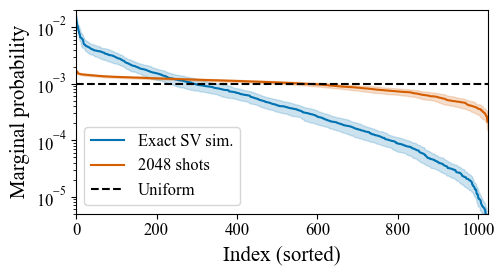

In [27]:
SHOTS_TO_PLOT = [None, 2048]
PLOT_LOG = False

plt.figure(figsize=(5.3, 3))
for shots in SHOTS_TO_PLOT:

    probabilities = probabilities_dict_exact[shots]
    probabilities = np.sum(probabilities.reshape(BATCH_SIZE, 1024, 2), axis=2)
    probabilities_mean = np.mean(probabilities, axis=0)
    probabilities_std = np.std(probabilities, axis=0)
    probabilities_sem = probabilities_std / np.sqrt(BATCH_SIZE)

    uniform_prob = 1/1024
    kl_divergences = np.sum(probabilities * np.log(probabilities / uniform_prob), axis=1)

    kl_divergence_mean = np.mean(kl_divergences)
    kl_divergence_std = np.std(kl_divergences)
    print(f'Shots={shots}, KL = {kl_divergence_mean:.6f} +/- {kl_divergence_std:.6f}')

    plt.plot(np.sort(probabilities_mean)[::-1], label=f'{shots} shots' if shots==2048 else 'Exact SV sim.', color=COLOR_DICT[shots])
    plt.fill_between(np.arange(len(probabilities_mean)),
                     np.sort(probabilities_mean - probabilities_sem)[::-1],
                     np.sort(probabilities_mean + probabilities_sem)[::-1],
                     color=COLOR_DICT[shots], alpha=0.2)

plt.axhline(y=1/1024, color='black', linestyle='--', label='Uniform')

if PLOT_LOG:
    plt.xscale('log', base=10)
    plt.xticks([10**i for i in range(4)], [str(10**i) for i in range(4)])
    plt.xlim(1000/1024, 1024)
    plt.yscale('log')
    plt.ylim(0.03/1000, 0.03)
    plt.legend(loc='lower left')
else:
    plt.ylim(1/200000, 0.02)
    plt.xlim(0, 1024)
    plt.yscale('log')
    # plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    plt.legend(loc='lower left')
plt.xlabel('Index (sorted)')
plt.ylabel('Marginal probability')

plt.tight_layout()

ax = plt.gca()
pos = ax.get_position()
print(pos)


LEFT = pos.x0
BOTTOM = pos.y0
RIGHT = pos.x1
TOP = pos.y1

if SAVE_PLOTS_TO_DISK:
    plt.savefig('plots_paper/fig7a.pdf')
plt.show()

## Figure 7b: Example images for 2048 shots vs exact simulation (from exact vs sampled training)

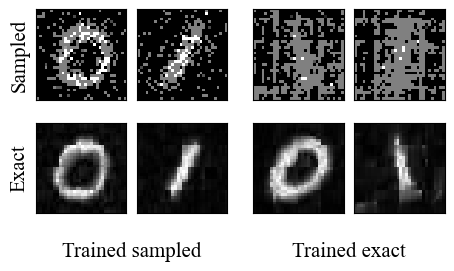

In [28]:
import matplotlib.pyplot as plt

# === target margins from the other figure's Bbox (figure fractions) ===
# LEFT   = 0.14816561844863735
# BOTTOM = 0.24592592592592588
# RIGHT  = 0.9442253832547169
# TOP    = 0.871111111111111

INNER_W = RIGHT - LEFT
INNER_H = TOP - BOTTOM

# sizes in inches (content layout, same as your original)
TILE_SIZE = 1.2      # width = height of each tile
TILE_SEP  = 0.1      # gap between tiles inside a group
GROUP_SEP = 0.3      # gap between groups (both horizontal and vertical)

# --- content layout math (in inches) ---
group_w = 2*TILE_SIZE + TILE_SEP
content_w = group_w*2 + GROUP_SEP
content_h = 2*TILE_SIZE + GROUP_SEP

# The actual figure size should match your reference figure
fig = plt.figure(figsize=(5.3, 3))

# Helper: map "content inches" -> figure-fraction coords inside the target inner rect
def fx(x_in):  # left/right mapping
    return LEFT + INNER_W * (x_in / content_w)

def fy(y_in):  # bottom/top mapping
    return BOTTOM + INNER_H * (y_in / content_h)

# Helper: map content sizes (in inches) -> figure-fraction widths/heights
def fw(w_in):
    return INNER_W * (w_in / content_w)

def fh(h_in):
    return INNER_H * (h_in / content_h)

ax = [[None]*4 for _ in range(2)]

# x positions (two groups of two) in *content inches*
x0 = 0.0
x1 = x0 + TILE_SIZE + TILE_SEP
x2 = x0 + group_w + GROUP_SEP
x3 = x2 + TILE_SIZE + TILE_SEP

# y positions (row 0 = top, row 1 = bottom) in *content inches*
y_top    = TILE_SIZE + GROUP_SEP
y_bottom = 0.0

# axes: map positions/sizes through fx/fy and fw/fh
ax[0][0] = fig.add_axes([fx(x0), fy(y_top),    fw(TILE_SIZE), fh(TILE_SIZE)])
ax[0][1] = fig.add_axes([fx(x1), fy(y_top),    fw(TILE_SIZE), fh(TILE_SIZE)])
ax[0][2] = fig.add_axes([fx(x2), fy(y_top),    fw(TILE_SIZE), fh(TILE_SIZE)])
ax[0][3] = fig.add_axes([fx(x3), fy(y_top),    fw(TILE_SIZE), fh(TILE_SIZE)])

ax[1][0] = fig.add_axes([fx(x0), fy(y_bottom), fw(TILE_SIZE), fh(TILE_SIZE)])
ax[1][1] = fig.add_axes([fx(x1), fy(y_bottom), fw(TILE_SIZE), fh(TILE_SIZE)])
ax[1][2] = fig.add_axes([fx(x2), fy(y_bottom), fw(TILE_SIZE), fh(TILE_SIZE)])
ax[1][3] = fig.add_axes([fx(x3), fy(y_bottom), fw(TILE_SIZE), fh(TILE_SIZE)])

# --- plotting code (example, replace with your actual) ---
ax[0][0].imshow(images_dict_sampled[2048][2].reshape(32, 32), cmap='gray', interpolation='nearest')
ax[0][1].imshow(images_dict_sampled[2048][1].reshape(32, 32), cmap='gray', interpolation='nearest')
ax[0][2].imshow(images_dict_sampled[None][0].reshape(32, 32), cmap='gray', interpolation='nearest')
ax[0][3].imshow(images_dict_sampled[None][1].reshape(32, 32), cmap='gray', interpolation='nearest')
ax[0][0].set_ylabel('Sampled', fontsize=15)

ax[1][0].imshow(images_dict_exact[2048][0].reshape(32, 32), cmap='gray', interpolation='nearest')
ax[1][1].imshow(images_dict_exact[2048][1].reshape(32, 32), cmap='gray', interpolation='nearest')
ax[1][2].imshow(images_dict_exact[None][0].reshape(32, 32), cmap='gray', interpolation='nearest')
ax[1][3].imshow(images_dict_exact[None][1].reshape(32, 32), cmap='gray', interpolation='nearest')
ax[1][0].set_ylabel('Exact', fontsize=15)

for row in ax:
    for a in row:
        a.set_xticks([]); a.set_yticks([])

# --- group titles ---
# Place titles inside the bottom margin so overall top/bottom whitespace stays identical.
mid_group1 = (x0 + x1 + TILE_SIZE) / 2
mid_group2 = (x2 + x3 + TILE_SIZE) / 2

title_y_in_figfrac = BOTTOM * 0.35  # e.g., 12% up inside the bottom margin
fig.text(LEFT + INNER_W * (mid_group1 / content_w), title_y_in_figfrac,
         "Trained sampled", ha='center', va='bottom', fontsize=15)
fig.text(LEFT + INNER_W * (mid_group2 / content_w), title_y_in_figfrac,
         "Trained exact", ha='center', va='bottom', fontsize=15)

# IMPORTANT: do NOT use bbox_inches='tight' if you want the same whitespace.
if SAVE_PLOTS_TO_DISK:
    fig.savefig("plots_paper/fig7b.pdf")
plt.show()

# Figure 10: Patch-QGAN benchmarks

***Note for Patch-QGAN samples:***
This uses the images generated by the Path-QGAN model (either after training or loading from checkpoint). Make sure to run the relevant code in PatchQGAN_benchmark.ipynb before the following cells

***Note for QGAN samples (comparison):***
This uses the images that were generated (and stored as PNGs) during the FID and MMD evaluation in FID_and_MMD_evaluation.ipynb. Make sure to run that notebook before the following cells

In [ ]:
from PIL import Image

In [ ]:
image_path_lookup = {
    "patch_MNIST": "images_FID/fake_MNIST_PatchQGAN",
    "patch_FashionMNIST": "images_FID/fake_FashionMNIST_PatchQGAN",
    "ours_MNIST": "images_FID/fake_MNIST_0_1_2_abl_specific",
    "ours_FashionMNIST": "images_FID/fake_FashionMNIST_over_0_1",
}
n_images_per_experiment = 9

In [ ]:
all_experiments = {}
for key, path in image_path_lookup.items():
    # load images from path
    images = []
    for filename in sorted(os.listdir(path)):
        if filename.endswith(".png"):
            img = Image.open(os.path.join(path, filename)).convert("L")
            # to numpy array and normalize to [0, 1]
            img_array = np.array(img).astype(np.float32) / 255.0
            images.append(img_array)

            if len(images) >= n_images_per_experiment:
                break
    all_experiments[key] = images

In [ ]:
subfigs = {
    "patch_MNIST": "a",
    "patch_FashionMNIST": "b",
    "ours_MNIST": "c",
    "ours_FashionMNIST": "d",
}

In [ ]:
for key in all_experiments:
    plot_save_path = os.path.join("plots_paper", f"fig16{subfigs[key]}.pdf")

    plot_encoding_circuits_consistent_spacing(
        rows_labels=[None], cols_labels=[None],
        images=iter(np.array(all_experiments[key])),
        grid_shape=(3, 3),
        tile_size=TILE_SIZE,
        tile_sep=TILE_SEP,
        row_sep=COL_SEP,
        col_sep=COL_SEP,
        margins=(1.0, 0.8, 0.9, 0.8),
        title_pad_in=0.35,
        row_label_pad_in=0.35,
        seed=42,
        save_path=plot_save_path if SAVE_PLOTS_TO_DISK else None
    )

# APPENDIX: Additional figures & tables

# Table 2: Generator configurations, requirements and resource estimates

In [29]:
from qugen.main.generator.quantum_circuits import generator_factory

inputs = [
    {'Image Shape': (4, 4), 'Color': False, 'Layers': (8, 2), 'Modes': 2},
    {'Image Shape': (8, 8), 'Color': False, 'Layers': (8, 2), 'Modes': 2},
    {'Image Shape': (16, 16), 'Color': False, 'Layers': (8, 2), 'Modes': 2},

    {'Image Shape': (32, 32), 'Color': False, 'Layers': (8, 2), 'Modes': 2},
    {'Image Shape': (32, 32), 'Color': False, 'Layers': (8, 2), 'Modes': 10},
    {'Image Shape': (32, 32), 'Color': False, 'Layers': (16, 2), 'Modes': 3},
    {'Image Shape': (32, 32), 'Color': False, 'Layers': (16, 2), 'Modes': 10},

    {'Image Shape': (32, 32), 'Color': False, 'Layers': (32, 2), 'Modes': 10},
    {'Image Shape': (32, 32), 'Color': False, 'Layers': (32, 2), 'Modes': 20},
    {'Image Shape': (32, 32), 'Color': False, 'Layers': (32, 2), 'Modes': 40},


    {'Image Shape': (32, 32), 'Color': False, 'Layers': (64, 2), 'Modes': 40},

    {'Image Shape': (32, 32), 'Color': True, 'Layers': (32, 2), 'Modes': 3},


    {'Image Shape': (64, 64), 'Color': True, 'Layers': (64, 2), 'Modes': 10},
    {'Image Shape': (128, 128), 'Color': True, 'Layers': (64, 2), 'Modes': 10},
    {'Image Shape': (1024, 1024), 'Color': True, 'Layers': (64, 2), 'Modes': 10},
]



table = pd.DataFrame(inputs)

In [30]:
def num_parameters(model_type, n_qubits, n_address_qubits, layers, noise_modes):
    if model_type == 'agnostic':
        #n_qubits = round(np.log2(img_size ** 2))
        params_per_layer = 0
        params_per_layer += n_qubits * 3  # angle encoding (three rotations)
        params_per_layer += 2*noise_modes*n_qubits  # noise encoding (one rotation)
        total_params = layers * params_per_layer
    elif model_type == 'specific':
        #n_address_qubits = round(np.log2(img_size ** 2))
        #n_qubits = n_address_qubits + 1 # including color qubit

        layers, sub_layers = layers
        params_per_sub_layer = 4 * (n_address_qubits - 1) * 2  # NN and NNN entangling

        params_per_layer = sub_layers * params_per_sub_layer
        params_per_layer += 2*noise_modes*n_address_qubits  # noise encoding (one rotation)
        params_per_layer += n_qubits # controlled rotations

        total_params = layers * params_per_layer
    else:
        raise ValueError("Unknown model type")

    return total_params

In [31]:
import jax.numpy as jnp
# add columns: Qubits, Parameters, CNOT est.
def determine_outputs(row):
    img_size = row['Image Shape'][0] * row['Image Shape'][1]
    channels = 3 if row['Color'] else 1
    n_qubits = int(np.ceil(np.log2(img_size * channels))) + 1

    # Parameters estimation (rough)
    row['Parameters'] = num_parameters(model_type='specific',
                                       n_qubits=n_qubits,
                                       n_address_qubits=n_qubits - (3 if row['Color'] else 1),
                                       layers=row['Layers'],
                                       noise_modes=row['Modes'])

    row['Qubits'] = n_qubits

    # CNOT estimation (rough)

    generator_kwargs = dict(circuit_depth=row['Layers'],
                            n_qubits=n_qubits,
                            n_ancilla_qubits=0,
                            #measurement_fn=self.measurement_process,
                            #noise_tuning=self.noise_tuning,
                            reupload=0)

    gen_fn = generator_factory("color_rot_skip_SO4_blocks_noise_angle_next_neighbor_mirror")
    print(gen_fn)
    qnode, noise_shape, init_noise_shape, params_shape = gen_fn(**generator_kwargs)
    qnode = qnode._fun
    dummy_noise_inputs = jnp.ones(noise_shape)
    dummy_init_noise_inputs = jnp.ones(init_noise_shape)
    dummy_params = jnp.zeros(params_shape)

    qnode = qml.transforms.decompose(qnode, gate_set={'RX', 'RY', 'RZ', 'CNOT'}, max_expansion=10)
    specs = qml.specs(qnode, level="device")(inputs=(dummy_noise_inputs, dummy_init_noise_inputs), weights=dummy_params)
    row['CNOT est.'] = f"{specs['resources'].gate_types.get('CNOT', -1)} / {specs['resources'].num_gates}"
    row['Depth est.'] = specs['resources'].depth
    assert specs['resources'].num_wires == n_qubits
    n_multi_qubit_gates = specs['resources'].num_gates - specs['resources'].gate_sizes.get(1, 0)
    assert specs['resources'].gate_types.get('CNOT', -1) == n_multi_qubit_gates, f"Mismatch in multi-qubit gate count: {specs['resources'].gate_types} vs {specs['resources'].gate_sizes}"
    #cnot_per_layer = n_qubits * (n_qubits - 1)  # rough estimate: full entangling layer
    #total_cnot = n_layers * cnot_per_layer
    #row['CNOT est.'] = total_cnot

    return row

In [32]:
with silent():
    table = table.apply(determine_outputs, axis=1)

In [33]:
# post process table for better display
table['Image Shape'] = table['Image Shape'].apply(lambda x: f"${x[0]} \\times {x[1]}$")
table['Layers'] = table['Layers'].apply(lambda x: f"{x[0]} ({x[1]})")
table['Color'] = table['Color'].apply(lambda x: 'RGB' if x else 'Gray')


In [34]:
if SAVE_PLOTS_TO_DISK:
    table.to_latex(os.path.join("plots_paper", "table1.tex"), index=False)
print(table.to_latex(index=False))

\begin{tabular}{lllrrrlr}
\toprule
Image Shape & Color & Layers & Modes & Parameters & Qubits & CNOT est. & Depth est. \\
\midrule
$4 \times 4$ & Gray & 8 (2) & 2 & 552 & 5 & 224 / 719 & 411 \\
$8 \times 8$ & Gray & 8 (2) & 2 & 888 & 7 & 384 / 1221 & 675 \\
$16 \times 16$ & Gray & 8 (2) & 2 & 1224 & 9 & 544 / 1723 & 939 \\
$32 \times 32$ & Gray & 8 (2) & 2 & 1560 & 11 & 704 / 2225 & 1203 \\
$32 \times 32$ & Gray & 8 (2) & 10 & 2840 & 11 & 704 / 2225 & 1203 \\
$32 \times 32$ & Gray & 16 (2) & 3 & 3440 & 11 & 1408 / 4417 & 2371 \\
$32 \times 32$ & Gray & 16 (2) & 10 & 5680 & 11 & 1408 / 4417 & 2371 \\
$32 \times 32$ & Gray & 32 (2) & 10 & 11360 & 11 & 2816 / 8801 & 4707 \\
$32 \times 32$ & Gray & 32 (2) & 20 & 17760 & 11 & 2816 / 8801 & 4707 \\
$32 \times 32$ & Gray & 32 (2) & 40 & 30560 & 11 & 2816 / 8801 & 4707 \\
$32 \times 32$ & Gray & 64 (2) & 40 & 61120 & 11 & 5632 / 17569 & 9379 \\
$32 \times 32$ & RGB & 32 (2) & 3 & 6944 & 13 & 3456 / 10791 & 5739 \\
$64 \times 64$ & RGB & 64 (2)

# Figure 13: Learning curves of MMD and loss for largest QGANs on MNIST and Fashion-MNIST

In [35]:
metric_labels_lookup = {
    "mmd_linear": "$\\kappa_{\\mathrm{linear}}$",#"MMD linear",
    "mmd_poly": "$\\kappa_{\\mathrm{poly}}$",#"MMD poly",
    "mmd_rbf": "$\\kappa_{\\mathrm{RBF}}$", #"MMD RBF",
    "is": "Inception Score",
    "fid_2048": "FID",
    "mifid_2048": "MiFID",
    "fid_64": "FID (64)",
    "mifid_64": "MiFID (64)",
    "loss_generator": "Generator ${L}_G$",
    "loss_discriminator": "Discriminator ${L}_D$",
}

In [36]:
import pandas as pd

def load_eval_data(experiment_path):
    return pd.read_csv(os.path.join(experiment_path, "evaluation_summary.csv"))

# python
def annotate_best(ax, x, y, label="Picked\nmodel", color="red", offset=(0, 12)):
    ax.annotate(
        label,
        xy=(x, y),                # point to annotate
        xytext=offset,            # text offset in points
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=color,
        linespacing=0.95,
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=1.5,
            shrinkA=0,
            shrinkB=0,
            alpha=0.9,
            mutation_scale=12
        )
    )

def plot_learning_curves(df, metric, skip_first_n_iters=0, ax=None, normalize=None, plot_average_curve=False, rolling_avg=None, mark_min=False):
    # Plots metric column over 'iteration' column:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    if isinstance(metric, str):
        metric = [metric]

    df = df[df['iteration'] >= skip_first_n_iters]

    ys_plotted = []
    for m in metric:
        df = df.dropna(subset=[m])
        ys = df[m].values
        print(min(ys))

        if normalize is not None:
            p_low, p_high = np.percentile(df[m], sorted(normalize))
            ys = (ys - p_low) / (p_high - p_low)
            ax.set_ylim([-0.1, 3])

        # get label from lookup dict that matches the beginning of m:
        try:
            label = next( v for k, v in metric_labels_lookup.items() if m.startswith(k))
        except StopIteration:
            label = m
        ax.plot(df['iteration'], ys, label=label)

        orig_rgb = mpl.colors.to_rgb(ax.lines[-1].get_color())

        if rolling_avg is not None or plot_average_curve:
            # Modify last line to be lighter and not in legend
            if rolling_avg is not None and not plot_average_curve:
                ax.lines[-1].set_label("_nolegend_")
                alpha = 0.3
                lw = 0.5
            else:
                alpha = 0.7
                lw = 1.25
            rgb = alpha * np.array(orig_rgb) + (1 - alpha) * np.array((1., 1., 1.))
            ax.lines[-1].set_color(rgb)
            ax.lines[-1].set_linewidth(lw)

        if not plot_average_curve:
            if rolling_avg is not None:
                ys_roll_avg = pd.Series(ys).rolling(rolling_avg).mean().values
                # plot rolling avg with same color as previous line
                ax.plot(df['iteration'], ys_roll_avg, label=label, linewidth=2, color=orig_rgb)

            if mark_min:
                min_idx = np.argmin(ys)
                x_min = df["iteration"].values[min_idx]
                y_min = ys[min_idx]
                ax.plot(x_min, y_min, marker="o", color="red", ms=5)
                annotate_best(ax, x_min, y_min + 0.1, offset=(10, 20))

        ys_plotted.append(ys)

    if plot_average_curve and len(ys_plotted) > 1:
        ys_mean = np.mean(ys_plotted, axis=0)
        if rolling_avg is not None:
            ys_mean = pd.Series(ys_mean).rolling(rolling_avg, min_periods=1, center=True).mean().values
        ax.plot(df['iteration'], ys_mean, label='Avg.', color='black', linewidth=2, linestyle='--')

        if mark_min:
            min_idx = np.argmin(ys_mean)
            x_min = df["iteration"].values[min_idx]
            y_min = ys_mean[min_idx]
            ax.plot(x_min, y_min, marker="o", color="red", ms=5)
            annotate_best(ax, x_min, y_min + 0.1, offset=(10, 20))
            print(f"Min avg: {ys_mean[min_idx]:.4f} at iteration {df['iteration'].values[min_idx]}")

    ax.set_xlabel('Iteration')
    ax.legend(ncol=2)
    return ax

In [37]:
# Large models
#df = load_eval_data("experiments/continuous_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_8921f0fc")
df = load_eval_data("experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_c5f811fc")

eval_metrics = \
    [
        "mmd_linear",
        "mmd_poly",
        "mmd_rbf",
        #"is",
        #"fid_2048",
        #"mifid_2048",
        #"fid_64",
        #"mifid_64"
    ]
n_samples = 5000
eval_metrics = [m + f"_n{n_samples}" for m in eval_metrics]


In [38]:
loss_metrics = [
    "loss_generator",
    "loss_discriminator",
]

Processing MNIST...
0.5448228485830953
82.18407222754013
0.0016289092749916
Min avg: 0.3670 at iteration 37000
-3.4289499156424124
-14.087964320030975
Processing Fashion-MNIST...
0.3621975846791088
136.23725204795485
0.0006831652517524
Min avg: 0.2366 at iteration 47000
-4.968058257981197
-10.132309524360958


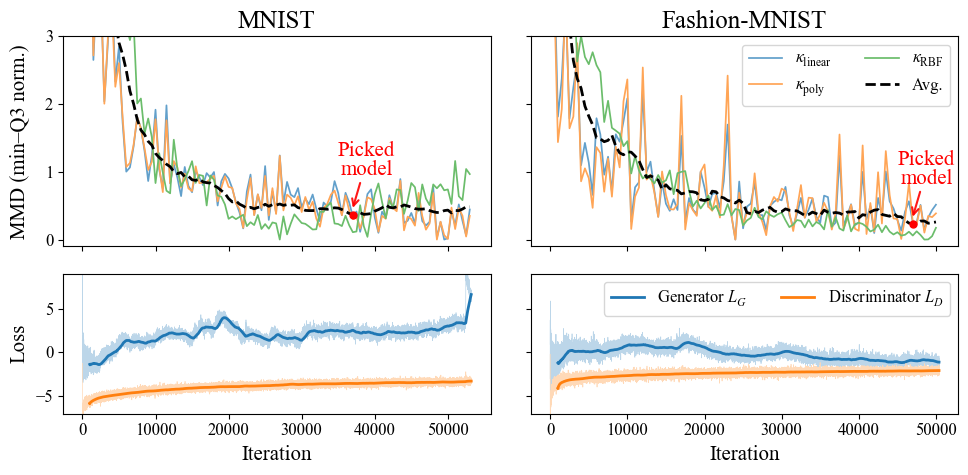

In [39]:
def plot_learning_curves_grid(mnist_path, fashion_mnist_path, svhn_path=None, rolling_avg_metric=9, save_plot_path=None, title=None):
    # 4 by 4 figure: two cols (MNIST and Fashion-MNIST), two rows (MMD eval curves, loss curves)

    sep_x=COL_SEP        # inches between subplots horizontally
    sep_y=COL_SEP        # inches between subplots vertically

    n_cols = 2 if svhn_path is None else 3
    fig, ax = plt.subplots(2, n_cols, figsize=(10, 5), sharex="col", sharey="row", gridspec_kw={'height_ratios': [1.8, 1.2]})
    fig.subplots_adjust(hspace=sep_x, wspace=sep_y)


    dfs = OrderedDict()
    dfs["MNIST"] = load_eval_data(mnist_path)
    if fashion_mnist_path is not None:
        dfs["Fashion-MNIST"] = load_eval_data(fashion_mnist_path)
    if svhn_path is not None:
        dfs["SVHN"] = load_eval_data(svhn_path)
    for idx, (data_label, df) in enumerate(dfs.items()):

        print(f"Processing {data_label}...")

        # eval plots (top row)
        eval_metrics = \
            [
                "mmd_linear",
                "mmd_poly",
                "mmd_rbf"
            ]
        n_samples = 5000
        eval_metrics = [m + f"_n{n_samples}" for m in eval_metrics]
        plot_learning_curves(df, eval_metrics, skip_first_n_iters=0, normalize=(0, 75), plot_average_curve=True, rolling_avg=rolling_avg_metric, ax=ax[0, idx], mark_min=True)
        ax[0, idx].set_title(data_label)
        ax[0, idx].set_xlabel("")

        # loss plots (bottom row)
        loss_metrics = [
            "loss_generator",
            "loss_discriminator",
        ]
        plot_learning_curves(df, loss_metrics, skip_first_n_iters=0, rolling_avg=1000, ax=ax[1, idx])

    ax[1, 0].set_ylim([-7, +9])
    ax[1, 0].set_ylabel("Loss")
    ax[0, 0].set_ylabel("MMD (min–Q3 norm.)")
    ax[0, 0].get_legend().remove()
    ax[1, 0].get_legend().remove()
    fig.align_ylabels()
    if title is not None:
        plt.suptitle(title)
    plt.tight_layout()


    # for letter, a in zip(map(chr, range(ord('a'), ord('a') + ax.size)), ax.flatten()):
    #     bbox = a.get_tightbbox(fig.canvas.get_renderer())
    #     offset = -14 if letter < 'c' else 10
    #     fig.text(bbox.x0 - 8, bbox.y1 + offset, f"{letter})", fontsize=15, va="top", ha="left",
    #          transform=None)

    if save_plot_path is not None:
        plt.savefig(save_plot_path)
    plt.show()

plot_learning_curves_grid(mnist_path="experiments/continuous_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_8921f0fc",
                          fashion_mnist_path="experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_c5f811fc",
rolling_avg_metric=9,
                          save_plot_path="plots_paper/fig11.pdf" if SAVE_PLOTS_TO_DISK else None)

# Table 3: FID and MMD comparison for all main text experiments

Table 3 is fully generated in LaTeX format in FID_and_MMD_evaluation.ipynb

# Figure 14: Layerwise entanglement entropy

In [59]:
experiment_path = "experiments/continuous_mnist_0_1_32x32_N_12665_minmax_qgan_f2e2366e"
epoch = 29500

n_layers = 8
n_modes = 2
n_samples = 100

In [60]:
from qugen.main.generator.continuous_qgan_model_handler import ContinuousQGANModelHandler

experiment_path = "experiments/continuous_mnist_0_1_32x32_N_12665_minmax_qgan_f2e2366e"
epoch = 29500

#experiment_path = "experiments/continuous_fashion_mnist_0_1_2_3_4_5_6_7_8_9_32x32_N_60000_minmax_qgan_cbf8da2e"
#epoch=36800

n_layers = 8
n_modes = 2
n_samples = 100

# Mode 0 for digit 0, Mode 1 for digit 1

image_progression = []
svs_progression = []
noise_modes_progression = []
for i_layer in tqdm(range(0, n_layers + 1, 1)):

    with silent():
        qgan = ContinuousQGANModelHandler()
        qgan.reload(os.path.basename(experiment_path), epoch=epoch)
        # Set all parameters after layer i_layer to zero
        qgan.generator_weights = qgan.generator_weights.at[i_layer:, ...].set(0.0)

    # fix random seed for reproducibility (jax key is fixed via constructing the ContinuousQGANModelHandler)
    np.random.seed(33)
    images, info = qgan.sample(n_samples=n_samples, return_measurement_outputs=True, return_noise=True)
    svs = info['measurement_outputs']
    noise_modes = info['noise']
    noise_modes = np.mean(noise_modes, axis=1).clip(0, n_modes - 1).round().astype(int)

    image_progression.append(images)
    svs_progression.append(svs)
    noise_modes_progression.append(noise_modes)




100%|██████████| 9/9 [01:00<00:00,  6.70s/it]


In [61]:
def subsystem_metric(full_state, data_qubits, metric, is_probs=False):
    # Possible metrics 'entropy'. Future could include concurrence, entanglement witness, etc.
    if is_probs:
        full_state = np.sqrt(full_state)

    red_state = qml.math.reduce_statevector(full_state, indices=data_qubits, check_state=True)
    if metric == 'entropy':
        return qml.math.vn_entropy(red_state, indices=range(len(data_qubits)), base=2., check_state=True)
    elif metric == 'mutual_information':  # for pure states, MI is twice the von Neumann entropy
        return 2*subsystem_metric(full_state=full_state, data_qubits=data_qubits,
                                metric='entropy', is_probs=False)
    else:
        raise NotImplementedError(f"Metric {metric} not implemented for ancilla metrics.")


In [62]:
vn_entropies = {
    'color': [],
    'address_same_dir': [],
    'address_fine_res': []
}
for i_layer, (svs, modes) in tqdm(enumerate(zip(svs_progression, noise_modes_progression))):
    # compute von Neumann entropies
    vn_ent_color = defaultdict(list)
    vn_ent_address_same_dir = defaultdict(list)
    vn_ent_address_fine_res = defaultdict(list)

    for sv, mode in zip(svs, modes):

        vn_entropy_color = subsystem_metric(full_state=sv, data_qubits=[0], metric='entropy', is_probs=True)
        vn_entropy_address_same_dir = subsystem_metric(full_state=sv, data_qubits=[0] + list(range(1, 11, 2)),
                                                       metric='entropy', is_probs=True)
        vn_entropy_address_fine_res = subsystem_metric(full_state=sv, data_qubits=range(9, 11), metric='entropy', is_probs=True)
        #print(f"Layer {i_layer} - Sample {i + 1} - Von Neumann Entropy of color qubit: {vn_entropy_color:.4f} bits, address qubits (same dir): {vn_entropy_address_same_dir:.4f} bits, address qubits (fine res): {vn_entropy_address_fine_res:.4f} bits")

        vn_ent_color[mode].append(vn_entropy_color)
        vn_ent_address_same_dir[mode].append(vn_entropy_address_same_dir)
        vn_ent_address_fine_res[mode].append(vn_entropy_address_fine_res)

    vn_entropies['color'].append(vn_ent_color)
    vn_entropies['address_same_dir'].append(vn_ent_address_same_dir)
    vn_entropies['address_fine_res'].append(vn_ent_address_fine_res)


9it [00:05,  1.65it/s]


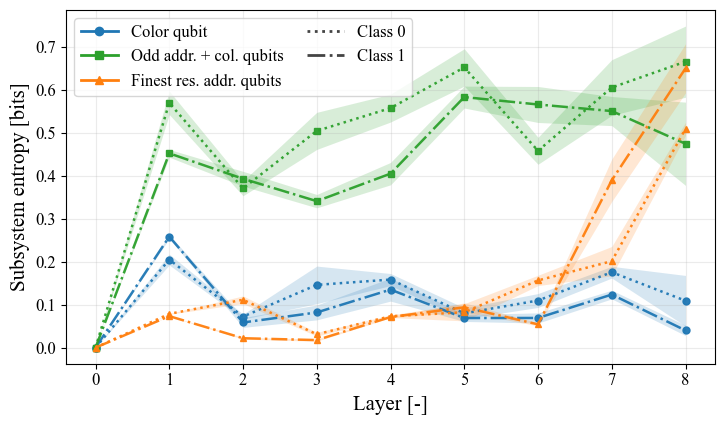

In [63]:
def mean_std(vals):
    arr = np.asarray(vals, dtype=float)
    if arr.size == 0:
        return np.nan, np.nan
    if arr.size == 1:
        return float(arr.mean()), 0.0
    return float(arr.mean()), float(arr.std(ddof=1))

subsystems = {
    'color': {'label': 'Color qubit', 'color': '#1f77b4', 'marker': 'o'},
    'address_same_dir': {'label': 'Odd addr. + col. qubits', 'color': '#2ca02c', 'marker': 's'},
    'address_fine_res': {'label': 'Finest res. addr. qubits', 'color': '#ff7f0e', 'marker': '^'},
}
linestyles = {0: ':', 1: '-.'}  # mode -> linestyle
dark_gray = '#444444'

layers = np.arange(len(vn_entropies['color']))

fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.5))

for subsystem_key, style in subsystems.items():
    layer_dicts = vn_entropies[subsystem_key]
    modes_present = sorted({m for d in layer_dicts for m in d.keys()})
    if not modes_present:
        continue
    for mode in modes_present:
        means, stds = [], []
        for d in layer_dicts:
            m, s = mean_std(d.get(mode, []))
            means.append(m); stds.append(s)
        means = np.asarray(means, dtype=float)
        stds = np.asarray(stds, dtype=float)

        mask = np.isfinite(means) & np.isfinite(stds)
        if not np.any(mask):
            continue
        L = layers[mask]
        M = means[mask]
        S = stds[mask]

        # std band
        ax.fill_between(L, M - S, M + S, color=style['color'], alpha=0.18, linewidth=0, zorder=1)
        # mean line
        ax.plot(
            L, M,
            color=style['color'],
            marker=style['marker'],
            linestyle=linestyles.get(mode, '-.'),
            linewidth=1.8, markersize=5, alpha=0.95, zorder=2
        )

ax.set_xlabel('Layer [-]')
ax.set_ylabel('Subsystem entropy [bits]')
#ax.set_title('Subsystem entropies over layers (mean ± std)')
ax.grid(True, alpha=0.25)

# python
from matplotlib.lines import Line2D

# Subsystems: colored solid line + marker
subsystem_handles = [
    Line2D(
        [0], [0],
        color=st['color'],
        marker=st['marker'],
        linestyle='-',
        linewidth=2.0,
        markersize=6,
        label=st['label'],
    )
    for st in subsystems.values()
]

# Modes: gray linestyles
mode_handles = [
    Line2D([0], [0], color=dark_gray, linestyle=ls, linewidth=2.0, label=f'Class {m}')
    for m, ls in linestyles.items()
]

# Single combined legend
handles = subsystem_handles + mode_handles
ax.legend(
    handles=handles,
    frameon=True,
    loc='upper left',
    ncol=2,
    columnspacing=1.4,
    handlelength=2.2,
)



plt.tight_layout()

# save plot:
plot_dir = "plots_paper"
os.makedirs(plot_dir, exist_ok=True)

if SAVE_PLOTS_TO_DISK:
    plt.savefig(os.path.join(plot_dir, "fig14.pdf"))

plt.show()

# Figure 16: FID and normalized MMD scores for different numbers of inference shots

In [11]:
# External evaluation imports
from pytorch_fid import fid_score
from qugen.main.data.mmd import mmd_linear, mmd_rbf, mmd_poly

# Model imports
from qugen.main.generator.continuous_qgan_model_handler import ContinuousQGANModelHandler
from qugen.main.generator.measurements import decoder_factory

In [12]:
# Okabe-Ito Colorblind-Friendly Palette for high-contrast publications
color_palette = {
    'fid': '#D55E00',       # Vermillion (Bold, clear)
    'mmd_lin': '#0072B2',   # Blue
    'mmd_rbf': '#009E73',   # Bluish Green
    'mmd_poly': '#CC79A7',  # Reddish Purple
}

# ---------------------------------------------------------------------------
# Experiment Configuration
# ---------------------------------------------------------------------------
SHOTS_SWEEP = [256, 512, 1024, 2048, 4096, 8192, 16384, None]
MODEL_SHOTS_2048 = 'continuous_mnist_0_1_32x32_N_12665_minmax_qgan_c9ece33a'
EPOCH = 15000
N_FID_SAMPLES = 10_000
BATCH_SIZE = 50

# ---> HARD-CODE YOUR PREFERRED IMAGE INDICES HERE <---
SAMPLE_INDICES = [102, 105]

REAL_DATA_TRAIN_NPY = 'apps/logistics/training_data/mnist_0_1_32x32_N_12665.npy'
REAL_DATA_TEST_NPY = 'apps/logistics/test_data/mnist_0_1_32x32.npy'

IMAGE_FOLDER_ROOT = 'images_FID/'
os.makedirs(IMAGE_FOLDER_ROOT, exist_ok=True)


# ---------------------------------------------------------------------------
# Helper Functions
# ---------------------------------------------------------------------------
def prepare_real_samples(image_folder, path_npy_samples, n_samples=N_FID_SAMPLES):
    image_folder_path = os.path.join(IMAGE_FOLDER_ROOT, image_folder)
    if os.path.exists(image_folder_path):
        print(f'{image_folder}: image folder already exists, skipping.')
        return
    os.makedirs(image_folder_path)

    images = np.load(path_npy_samples)
    np.random.seed(42)
    np.random.shuffle(images)
    images = images[:n_samples].clip(0, 255).astype(np.uint8)

    for i, img_arr in enumerate(images):
        Image.fromarray(img_arr, mode='L').save(
            os.path.join(image_folder_path, f'img_{i}.png'), compress_level=0
        )
    print(f'  -> Saved {len(images)} real images to {image_folder_path}')

def sample_model_to_npy(model_name, inference_shots, npy_path,
                        epoch=EPOCH, n_samples=N_FID_SAMPLES, batch_size=BATCH_SIZE):
    if os.path.exists(npy_path):
        print(f'  npy exists, skipping generation: {npy_path}')
        return

    model = ContinuousQGANModelHandler()
    model.reload(model_name=model_name, epoch=epoch)

    exact_decoder = decoder_factory(
        model.decoding_scheme,
        n_ancilla_qubits=model.n_ancilla_qubits,
        shots=None,
    )

    def robust_shot_decoder(measurement_outputs):
        exact_probs = exact_decoder(measurement_outputs)
        if inference_shots is None:
            return exact_probs
        probs_np = np.asarray(exact_probs, dtype=np.float64)
        probs_np = np.clip(probs_np, 0.0, 1.0)
        sampled_counts = np.random.binomial(n=inference_shots, p=probs_np)
        return sampled_counts / float(inference_shots)

    model.shots = inference_shots
    model.decoder = robust_shot_decoder

    all_samples = np.empty((n_samples, 32 * 32))
    n_collected = 0
    pbar = tqdm(total=n_samples, desc=f'  generating shots={inference_shots}')
    while n_collected < n_samples:
        n_batch = min(batch_size, n_samples - n_collected)
        batch = model.sample(n_batch)
        if np.isnan(batch).any():
            print(f"\n[!] ERROR: NaNs detected at sample {n_collected}. Aborting.")
            if os.path.exists(npy_path): os.remove(npy_path)
            return
        all_samples[n_collected:n_collected + n_batch] = batch.reshape(n_batch, -1)
        n_collected += n_batch
        pbar.update(n_batch)
    pbar.close()
    np.save(npy_path, all_samples)
    print(f'  -> Saved {n_collected} samples to {npy_path}')

def prepare_generated_samples(image_folder, npy_path, n_samples=N_FID_SAMPLES):
    image_folder_path = os.path.join(IMAGE_FOLDER_ROOT, image_folder)
    if os.path.exists(image_folder_path):
        print(f'{image_folder}: image folder already exists, skipping.')
        return
    os.makedirs(image_folder_path)

    images = np.load(npy_path)
    np.random.seed(42)
    np.random.shuffle(images)
    images = images[:n_samples]
    images = (255 * images).clip(0, 255).astype(np.uint8).reshape(-1, 32, 32)

    for i, img_arr in enumerate(images):
        Image.fromarray(img_arr, mode='L').save(
            os.path.join(image_folder_path, f'img_{i}.png'), compress_level=0
        )
    print(f'  -> Wrote {len(images)} PNGs to {image_folder_path}')

def compute_fid_stats(image_folder):
    stats_path = os.path.join(IMAGE_FOLDER_ROOT, f'{image_folder}.npz')
    if os.path.exists(stats_path):
        print(f'{image_folder}: FID stats already exist, skipping.')
        return
    image_folder_path = os.path.join(IMAGE_FOLDER_ROOT, image_folder)
    fid_score.save_fid_stats(
        paths=[image_folder_path, stats_path],
        batch_size=50, device=None, dims=2048,
        num_workers=0,
    )
    print(f'  -> Saved FID stats to {stats_path}')

def get_exact_fid(gen_folder, real_folder):
    gen_stats = os.path.join(IMAGE_FOLDER_ROOT, gen_folder + '.npz')
    real_stats = os.path.join(IMAGE_FOLDER_ROOT, real_folder + '.npz')
    return fid_score.calculate_fid_given_paths(
        paths=[gen_stats, real_stats],
        batch_size=50, device=None, dims=2048,
    )

def load_and_flatten_images(folder_path):
    file_paths = glob.glob(os.path.join(folder_path, "*.png"))
    if not file_paths:
        raise FileNotFoundError(f"No PNG images found in {folder_path}")
    img_list = []
    for fp in file_paths:
        img = Image.open(fp)
        img_array = np.array(img, dtype=np.float32).flatten() / 255.0
        img_list.append(img_array)
    return np.stack(img_list)


In [14]:
# -----------------------------------------------------------------------
# 1. Real data preparation
# -----------------------------------------------------------------------
REAL_TRAIN_FOLDER = 'real_MNIST_0_1'
REAL_TEST_FOLDER = 'test_real_MNIST_0_1'

print('=== Preparing real data ===')
prepare_real_samples(REAL_TRAIN_FOLDER, REAL_DATA_TRAIN_NPY)
compute_fid_stats(REAL_TRAIN_FOLDER)
prepare_real_samples(REAL_TEST_FOLDER, REAL_DATA_TEST_NPY)
Y_real_test = load_and_flatten_images(os.path.join(IMAGE_FOLDER_ROOT, REAL_TEST_FOLDER))

# -----------------------------------------------------------------------
# 2. Sweep over shot budgets
# -----------------------------------------------------------------------
fid_shots_model = {}
mmd_shots_model = {}

print('\n=== Model: shots_2048 ===')
for shots in SHOTS_SWEEP:
    label = str(shots) if shots is not None else 'exact'
    folder = f'shots_sweep_shots_2048_{label}'
    npy_path = os.path.join(IMAGE_FOLDER_ROOT, f'{folder}.npy')

    print(f'\n[shots_2048] inference shots = {label}')
    sample_model_to_npy(MODEL_SHOTS_2048, shots, npy_path)
    prepare_generated_samples(folder, npy_path)

    compute_fid_stats(folder)
    fid_val = get_exact_fid(folder, REAL_TRAIN_FOLDER)
    fid_shots_model[shots] = fid_val
    print(f'  -> FID = {fid_val:.2f}')

    X_gen = load_and_flatten_images(os.path.join(IMAGE_FOLDER_ROOT, folder))
    mmd_shots_model[shots] = {
        'linear': mmd_linear(X_gen, Y_real_test),
        'rbf': mmd_rbf(X_gen, Y_real_test, gamma=1 / X_gen.shape[1]),
        'poly': mmd_poly(X_gen, Y_real_test, gamma=1 / X_gen.shape[1])
    }
    print(f'  -> MMD Linear={mmd_shots_model[shots]["linear"]:.4f}, '
          f'RBF={mmd_shots_model[shots]["rbf"]:.4f}, '
          f'Poly={mmd_shots_model[shots]["poly"]:.4f}')

# -----------------------------------------------------------------------
# 3. Process & Normalize MMD Scores
# -----------------------------------------------------------------------
max_mmd = {
    'linear': max(v['linear'] for v in mmd_shots_model.values()),
    'rbf': max(v['rbf'] for v in mmd_shots_model.values()),
    'poly': max(v['poly'] for v in mmd_shots_model.values())
}

# -----------------------------------------------------------------------
# 4. Results Table
# -----------------------------------------------------------------------
print('\n' + '=' * 80)
print('FID & MMD vs. Shot Budget — MNIST digits 0 & 1 (32 x 32)')
print(f'N_FID_SAMPLES = {N_FID_SAMPLES}')
col = '{:>18}  {:>15}  {:>10}  {:>10}  {:>10}'
print(col.format('Shots/image', 'FID', 'MMD-Lin', 'MMD-RBF', 'MMD-Poly'))
print('-' * 80)
for shots in SHOTS_SWEEP:
    label = str(shots) if shots is not None else 'inf (SV exact)'
    fid_v = fid_shots_model[shots]
    lin_v = mmd_shots_model[shots]['linear']
    rbf_v = mmd_shots_model[shots]['rbf']
    poly_v = mmd_shots_model[shots]['poly']
    print(col.format(label, f'{fid_v:.2f}', f'{lin_v:.4f}', f'{rbf_v:.4f}', f'{poly_v:.4f}'))

=== Preparing real data ===
real_MNIST_0_1: image folder already exists, skipping.
real_MNIST_0_1: FID stats already exist, skipping.
test_real_MNIST_0_1: image folder already exists, skipping.

=== Model: shots_2048 ===

[shots_2048] inference shots = 256
  npy exists, skipping generation: images_FID/shots_sweep_shots_2048_256.npy
shots_sweep_shots_2048_256: image folder already exists, skipping.
shots_sweep_shots_2048_256: FID stats already exist, skipping.
  -> FID = 358.99
  -> MMD Linear=95.0224, RBF=0.1617, Poly=0.0216

[shots_2048] inference shots = 512
  npy exists, skipping generation: images_FID/shots_sweep_shots_2048_512.npy
shots_sweep_shots_2048_512: image folder already exists, skipping.
shots_sweep_shots_2048_512: FID stats already exist, skipping.
  -> FID = 346.41
  -> MMD Linear=53.0880, RBF=0.0909, Poly=0.0092

[shots_2048] inference shots = 1024
  npy exists, skipping generation: images_FID/shots_sweep_shots_2048_1024.npy
shots_sweep_shots_2048_1024: image folder al

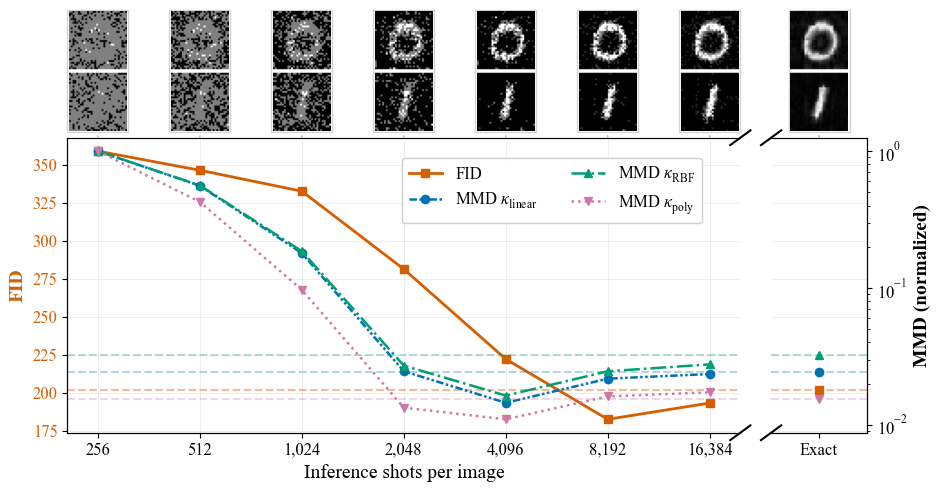

In [16]:

# -----------------------------------------------------------------------
# 5. Broken X-Axis Plotting & Overhead Image Grid
# -----------------------------------------------------------------------
finite_shots = [s for s in SHOTS_SWEEP if s is not None]
fid_finite = [fid_shots_model[s] for s in finite_shots]

fig = plt.figure(figsize=(10, 5))

# GridSpec: Main plot takes 7 parts width, Exact plot takes 1 part.
width_ratio_main = 7
width_ratio_exact = 1
gs = fig.add_gridspec(1, 2, width_ratios=[width_ratio_main, width_ratio_exact], wspace=0.08)

ax1_main = fig.add_subplot(gs[0, 0])
ax1_exact = fig.add_subplot(gs[0, 1], sharey=ax1_main)

# Clean the inner spines to create the visual "break"
ax1_main.spines['right'].set_visible(False)
ax1_exact.spines['left'].set_visible(False)
ax1_main.tick_params(axis='y', which='both', right=False)
ax1_exact.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# --- Primary Y-Axis: Standard FID ---
ax1_main.plot(finite_shots, fid_finite, marker='s', linewidth=2.0, markersize=6,
              linestyle='-', color=color_palette['fid'], label='FID')

if None in fid_shots_model:
    # Extend the baseline across both subplots
    ax1_main.axhline(fid_shots_model[None], linestyle='--', linewidth=1.5, color=color_palette['fid'], alpha=0.4)
    ax1_exact.axhline(fid_shots_model[None], linestyle='--', linewidth=1.5, color=color_palette['fid'], alpha=0.4)
    # Plot the exact dot
    ax1_exact.plot([1], [fid_shots_model[None]], marker='s', markersize=6, color=color_palette['fid'],
                   label='FID (SV Exact)')

# X-Axis configuration for main plot (Log2)
ax1_main.set_xscale('log', base=2)
ax1_main.set_xticks(finite_shots)
ax1_main.set_xticklabels([f"{int(x):,}" for x in finite_shots], fontsize=12)

# Kill all minor ticks to prevent the crazy overlapping labels
ax1_main.xaxis.set_minor_locator(ticker.NullLocator())
ax1_main.xaxis.set_minor_formatter(ticker.NullFormatter())

# X-Axis configuration for exact plot
ax1_exact.set_xlim(0.5, 1.5)
ax1_exact.set_xticks([1])
ax1_exact.set_xticklabels(['Exact'], fontsize=12)

# Axis Labels & Grids
ax1_main.set_xlabel('Inference shots per image', fontsize=14)
ax1_main.set_ylabel('FID', fontsize=14, color=color_palette['fid'], fontweight='bold')
ax1_main.tick_params(axis='y', labelcolor=color_palette['fid'])
ax1_main.grid(True, alpha=0.3, linestyle='-', which='major')
ax1_exact.grid(True, alpha=0.3, linestyle='-', axis='y')

# Mathematically correcting the diagonal cut slopes
d_y = 0.025            # Height of the cut marks
d_x_main = 0.015       # Width of the cut marks for the wide main plot
# Scale the width on the exact plot so physical slopes match perfectly
d_x_exact = d_x_main * (width_ratio_main / width_ratio_exact)

kwargs = dict(color='k', clip_on=False, linewidth=1.5)

# Draw cut on right edge of main plot
ax1_main.plot((1 - d_x_main, 1 + d_x_main), (-d_y, +d_y), transform=ax1_main.transAxes, **kwargs)
ax1_main.plot((1 - d_x_main, 1 + d_x_main), (1 - d_y, 1 + d_y), transform=ax1_main.transAxes, **kwargs)

# Draw identical cut on left edge of exact plot
ax1_exact.plot((-d_x_exact, +d_x_exact), (-d_y, +d_y), transform=ax1_exact.transAxes, **kwargs)
ax1_exact.plot((-d_x_exact, +d_x_exact), (1 - d_y, 1 + d_y), transform=ax1_exact.transAxes, **kwargs)

# --- Secondary Y-Axis: Normalized MMD ---
ax2_main = ax1_main.twinx()
ax2_exact = ax1_exact.twinx()
ax2_exact.sharey(ax2_main)

ax2_main.spines['right'].set_visible(False)
ax2_exact.spines['left'].set_visible(False)

# Apply the log scale FIRST
ax2_main.set_yscale('log')
ax2_exact.set_yscale('log')

# NOW turn off the spines and ticks (so set_yscale doesn't turn them back on!)
ax2_main.spines['right'].set_visible(False)
ax2_exact.spines['left'].set_visible(False)


ax1_main.tick_params(axis='y', which='both', left=True, right=False, labelright=False)
ax1_exact.tick_params(axis='y', which='both', left=False, right=False, labelright=False)


ax2_main.tick_params(axis='y', which='both', left=False, right=False, labelright=False)
ax2_exact.tick_params(axis='y', which='both', left=False, right=True, labelright=True)

ax2_exact.set_ylabel('MMD (normalized)', fontsize=14, color='black', fontweight='bold')

kernel_styles = {
    'linear': {'color': 'mmd_lin', 'marker': 'o', 'ls': (0, (3, 1, 1, 1, 1, 1)), 'label': r'MMD $\kappa_{\rm linear}$'},
    'rbf': {'color': 'mmd_rbf', 'marker': '^', 'ls': '-.', 'label': r'MMD $\kappa_{\rm RBF}$'},
    'poly': {'color': 'mmd_poly', 'marker': 'v', 'ls': ':', 'label': r'MMD $\kappa_{\rm poly}$'},
}

for k in ['linear', 'rbf', 'poly']:
    st = kernel_styles[k]
    norm_finite_vals = [mmd_shots_model[s][k] / max_mmd[k] for s in finite_shots]

    ax2_main.plot(finite_shots, norm_finite_vals, marker=st['marker'],
                  linestyle=st['ls'], linewidth=1.8, markersize=6,
                  color=color_palette[st['color']], label=st['label'])

    if None in mmd_shots_model:
        sv_norm_val = mmd_shots_model[None][k] / max_mmd[k]
        ax2_main.axhline(sv_norm_val, linestyle='--', color=color_palette[st['color']], alpha=0.3)
        ax2_exact.axhline(sv_norm_val, linestyle='--', color=color_palette[st['color']], alpha=0.3)
        ax2_exact.plot([1], [sv_norm_val], marker=st['marker'], markersize=6, color=color_palette[st['color']])


# Centering the Legend Away from the Cut
lines_1, labels_1 = ax1_main.get_legend_handles_labels()
lines_2, labels_2 = ax2_main.get_legend_handles_labels()

if None in mmd_shots_model:
    labels_2.extend(['MMD Linear (SV)', 'MMD RBF (SV)', 'MMD Poly (SV)'])

# Anchor safely inside the wide upper-right void of ax1_main, far away from the cut marks
# Added ncol=2 to make it wider and fit beautifully in the empty space
ax1_main.legend(lines_1 + lines_2, labels_1 + labels_2,
                loc='upper center', bbox_to_anchor=(0.72, 0.96), ncol=2,
                frameon=True, framealpha=0.95)

# --- Plot the Floating Image Overlays ---
for shots in SHOTS_SWEEP:
    is_exact = shots is None
    x_pos = 1 if is_exact else shots
    ax_target = ax1_exact if is_exact else ax1_main

    folder = f'shots_sweep_shots_2048_{str(shots) if not is_exact else "exact"}'
    npy_path = os.path.join(IMAGE_FOLDER_ROOT, f'{folder}.npy')
    data = np.load(npy_path)

    img1 = data[SAMPLE_INDICES[0]].reshape(32, 32)
    img2 = data[SAMPLE_INDICES[1]].reshape(32, 32)

    # Stack vertically with a clean 2px white gap
    separator = np.ones((2, 32))
    img_comb = np.vstack([img1, separator, img2])

    imagebox = OffsetImage(img_comb, zoom=1.3, cmap='gray')

    ab = AnnotationBbox(imagebox, (x_pos, 1.0),
                        xycoords=('data', 'axes fraction'),
                        boxcoords="offset points",
                        xybox=(0, 48),
                        pad=0.1,
                        arrowprops=dict(arrowstyle="-", color="gray", alpha=0.5),
                        frameon=True, bboxprops=dict(edgecolor='lightgray', facecolor='white'))
    ax_target.add_artist(ab)

# Adjusted to eliminate excess right-side whitespace now that the legend is internal
plt.subplots_adjust(top=0.74, bottom=0.15, right=0.90, left=0.1)

if SAVE_PLOTS_TO_DISK:
    plt.savefig('plots_paper/fid_mmd_vs_shots.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Figure 17: Gradient scaling

In [ ]:
grad_scale_experiments = [
    "experiments/continuous_mnist_0_1_16x16_N_12665_minmax_qgan_eaf279f6",
    "experiments/continuous_mnist_0_1_16x16_N_12665_minmax_qgan_5feca26e",
    "experiments/continuous_mnist_0_1_8x8_N_12665_minmax_qgan_666bec0e",
    "experiments/continuous_mnist_0_1_8x8_N_12665_minmax_qgan_ca69ce0a",
    "experiments/continuous_mnist_0_1_4x4_N_12665_minmax_qgan_dd276b03",
    "experiments/continuous_mnist_0_1_4x4_N_12665_minmax_qgan_a718e85d",
    "experiments/continuous_mnist_0_1_2_32x32_N_18623_minmax_qgan_7f68e3ee",
    "experiments/continuous_mnist_0_1_32x32_N_12665_minmax_qgan_f2e2366e",
]

experiments_csv_path = "experiments_configs/runs.csv"
experiments_df = pd.read_csv(experiments_csv_path)
# filter out rows that are not in grad_scale_experiments list:
experiments_df = experiments_df[experiments_df['result_path'].isin(grad_scale_experiments)]
# sort df by data_set_img_size ascending
experiments_df = experiments_df.sort_values(by='data_set_img_size', ascending=True)

In [ ]:
def num_parameters(model_type, img_size, layers, noise_modes):
    if model_type == 'agnostic':
        n_qubits = round(np.log2(img_size ** 2))
        params_per_layer = 0
        params_per_layer += n_qubits * 3  # angle encoding (three rotations)
        params_per_layer += 2*noise_modes*n_qubits  # noise encoding (one rotation)
        total_params = layers * params_per_layer
    elif model_type == 'specific':
        n_address_qubits = round(np.log2(img_size ** 2))
        n_qubits = n_address_qubits + 1 # including color qubit

        layers, sub_layers = layers
        params_per_sub_layer = 4 * (n_address_qubits - 1) * 2  # NN and NNN entangling

        params_per_layer = sub_layers * params_per_sub_layer
        params_per_layer += 2*noise_modes*n_address_qubits  # noise encoding (one rotation)
        params_per_layer += n_qubits # controlled rotations

        total_params = layers * params_per_layer
    else:
        raise ValueError("Unknown model type")

    return total_params

In [ ]:
# Style maps
linestyle_map = {'agnostic': '-', 'specific': '--'}
marker_map = {'agnostic': 'o', 'specific': 's'}

# Build a consistent color map for image sizes using a gradient
unique_sizes = sorted(experiments_df['data_set_img_size'].astype(int).unique())
cmap = plt.get_cmap('viridis_r')
# avoid extremes of the colormap for better contrast
color_positions = np.linspace(0.2, 0.8, len(unique_sizes))
size_color = {size: cmap(pos) for size, pos in zip(unique_sizes, color_positions)}

fig, axes = plt.subplots(1, 2, width_ratios=[2, 1], figsize=(10, 4.5), sharey=True)

# Left plot: curves over iterations
plt.sca(axes[0])
means = {}
legend_seen = set()

for _, experiment in experiments_df.iterrows():  # iter in reverse order
    model_dir = experiment['result_path']
    eval_summary_file = os.path.join(model_dir, "evaluation_summary.csv")
    eval_summary_df = pd.read_csv(eval_summary_file)

    # Cap at 10_000 iterations for better visibility
    max_epoch = 5_000
    eval_summary_df = eval_summary_df[eval_summary_df['iteration'] <= max_epoch]

    data_set_img_size = int(experiment['data_set_img_size'])
    model_name = experiment['generator_name']
    model_type = 'agnostic' if 'strongly_ent' in model_name else 'specific'
    layers = literal_eval(experiment['circuit_depth'])

    # Number of params normalization
    num_params = num_parameters(model_type, data_set_img_size, layers, noise_modes=2)

    # Smooth and normalize
    eval_summary_df['grad_mag_generator_processed'] = (
        eval_summary_df['grad_mag_generator']
        .rolling(window=500, min_periods=1).mean()
        / num_params
    )

    color = size_color[data_set_img_size]
    label = f"Size: {data_set_img_size}, Type: {model_type}"
    # avoid duplicate legend entries
    plot_label = None if label in legend_seen else label
    if plot_label:
        legend_seen.add(label)

    plt.plot(
        eval_summary_df['iteration'],
        eval_summary_df['grad_mag_generator_processed'],
        color=color,
        linestyle=linestyle_map[model_type],
        linewidth=line_width,
        label=plot_label
    )

    # Mean after warmup
    mean_grad = eval_summary_df[eval_summary_df['iteration'] >= 1000]['grad_mag_generator_processed'].mean()
    means[(data_set_img_size, model_type)] = mean_grad

plt.xlabel('Iteration')
plt.ylabel('Rel. generator grad. magnitude $\\left\\Vert \\nabla L_{G}\\right\\Vert  / K $')
plt.yscale('log')
dark_gray = (0.25, 0.25, 0.25)


model_handles = [
    mpl.lines.Line2D([0], [0], color=dark_gray, linestyle='--', linewidth=line_width, label='specific'),
    mpl.lines.Line2D([0], [0], color=dark_gray, linestyle='-',  linewidth=line_width, label='agnostic'),
]
size_handles = [
    mpl.lines.Line2D([0], [0], color=size_color[s], linestyle='-', linewidth=line_width, label=f'{s}×{s}')
    for s in unique_sizes
]

axes[0].legend(
    handles=[*model_handles, *size_handles],
    loc='best',
    ncol=min(len(unique_sizes) + 2, 3),
    handlelength=handlelength,
    frameon=True,
    columnspacing=0.8,
    handletextpad=0.6,
    borderpad=0.4,
    labelspacing=0.4
)

# Right plot: scatter + trend lines
plt.sca(axes[1])

for model_type in ['agnostic', 'specific']:
    x = []
    y = []
    cols = []
    for (img_size, m_type), mean_grad in means.items():
        if m_type == model_type:
            x.append(img_size ** 2)
            y.append(mean_grad)
            cols.append(size_color[img_size])

    # Scatter with model-type-specific marker, colors by image size
    plt.scatter(
        x, y,
        c=cols,
        marker=marker_map[model_type],
        edgecolors='none',
        s=80
    )

    if len(x) >= 2 and all(v > 0 for v in y):
        # Log-log fit: log10(y) ~ a * log2(x) + b
        coefficients = np.polyfit(np.log2(x), np.log10(y), 1)
        polynomial = np.poly1d(coefficients)
        x_fit = np.linspace(min(x) - 8, max(x) + 32**2, 200)
        y_fit = 10 ** polynomial(np.log2(x_fit))

        # Dark gray trend line with matching linestyle
        plt.plot(
            x_fit, y_fit,
            color=dark_gray,
            linestyle=linestyle_map[model_type],
            linewidth=line_width,
            # background (low z order)
            zorder=-1
        )

plt.yscale('log')
plt.xscale('log', base=2)
plt.xlabel('Image Size (# pixels)')

# Custom legend (right plot)
custom_handles = [

    mpl.lines.Line2D([0], [0],
           color=dark_gray,
           linestyle='--',
           marker='s',
           markersize=6,
           linewidth=line_width,
           label='specific'),
    mpl.lines.Line2D([0], [0],
           color=dark_gray,
           linestyle='-',
           marker='o',
           markersize=6,
           linewidth=line_width,
           label='agnostic')
]
plt.legend(handles=custom_handles, loc='best')

# align x labels vertically:
fig.align_xlabels(axes)



plt.tight_layout()
fig.subplots_adjust(wspace=0.1)


from matplotlib.patches import ConnectionPatch
from matplotlib import transforms
import numpy as np

# Per-type mean y (data coordinates)
specific_vals = [v for (s, t), v in means.items() if t == 'specific']
agnostic_vals = [v for (s, t), v in means.items() if t == 'agnostic']
y_specific = float(np.mean(specific_vals)) if specific_vals else None
y_agnostic = float(np.mean(agnostic_vals)) if agnostic_vals else None

# X in axes coords (slightly inside edges to be shorter)
xA_ax, xB_ax = 1.01, -0.02

# Blended transforms: x=axes coords, y=data coords
transA = transforms.blended_transform_factory(axes[0].transAxes, axes[0].transData)
transB = transforms.blended_transform_factory(axes[1].transAxes, axes[1].transData)

# Optional: clear old arrows on re-run
for art in list(fig.artists):
    if isinstance(art, ConnectionPatch):
        art.remove()

# Dashed arrow for 'specific'
if y_specific is not None:
    fig.add_artist(ConnectionPatch(
        xyA=(xA_ax, y_specific), coordsA=transA,
        xyB=(xB_ax, y_specific), coordsB=transB,
        arrowstyle="-|>", linestyle="--",
        linewidth=1.6, color=dark_gray,
        mutation_scale=14, zorder=10
    ))

# Solid arrow for 'agnostic'
if y_agnostic is not None:
    fig.add_artist(ConnectionPatch(
        xyA=(xA_ax, y_agnostic), coordsA=transA,
        xyB=(xB_ax, y_agnostic), coordsB=transB,
        arrowstyle="-|>", linestyle="-",
        linewidth=1.6, color=dark_gray,
        mutation_scale=14, zorder=10
    ))

# Save figure
output_dir = "plots_paper"
os.makedirs(output_dir, exist_ok=True)
if SAVE_PLOTS_TO_DISK:
    plt.savefig(os.path.join(output_dir, "fig15.pdf"))
plt.show()